In [13]:
import h5py
import numpy as np
from matplotlib import pyplot as plt
import torch
import pickle
import os
import torch.nn.functional as F
from typing import Tuple
from tqdm import tqdm
import torch.nn as nn
from typing import Dict, NamedTuple, Optional, Sequence, Tuple, Union   
import re
import math
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

device=torch.device('cuda:2')

 
from dataclasses import dataclass



from sense_new import sense_v1

import time


In [14]:
import os, sys, pickle, math
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── Paths ─────────────────────────────────────────────────────────────────────
# Notebooks have no __file__, and the working directory differs between Jupyter
# (the notebook's folder) and VSCode (the workspace root). So instead of relying
# on either, locate the project root by walking up until we find its marker dirs.
def _find_project_root(start):
    p = os.path.abspath(start)
    while True:
        if os.path.isdir(os.path.join(p, 'edm_repo')) and \
           os.path.isdir(os.path.join(p, 'alps')):
            return p
        parent = os.path.dirname(p)
        if parent == p:            # reached filesystem root
            return None
        p = parent

# Search from the cwd, then from a few likely starting points.
PROJECT_ROOT = (
    _find_project_root(os.getcwd())
    or _find_project_root(os.path.join(os.getcwd(), 'alps'))
    or _find_project_root(os.path.join(os.getcwd(), '..'))
)
if PROJECT_ROOT is None:
    # Fallback: set manually if auto-detection fails.
    # PROJECT_ROOT = '/home2/wzr8sn/Work/cascade_diffusion_mri'
    raise RuntimeError(
        'Could not locate project root (a dir containing both edm_repo/ and '
        'alps/). Set PROJECT_ROOT manually in this cell.'
    )

for _p in [
    os.path.join(PROJECT_ROOT, 'edm_repo'),
    os.path.join(PROJECT_ROOT, 'scripts'),
    PROJECT_ROOT,
]:
    if _p not in sys.path:
        sys.path.insert(0, _p)

print(f'Project root : {PROJECT_ROOT}')

Project root : /CBIG-Standard-ECE/Sahil/mri_cascaded_diffusion


In [15]:


GPU_ID = 2
device = torch.device(f'cuda:{GPU_ID}' if torch.cuda.is_available() else 'cpu')

# Checkpoint paths — the trained MRI EDM checkpoints live here:
CKPT_ROOT = '/CBIG-Standard-ECE/Sahil/mri_cascaded_diffusion/checkpoints'
SR_CKPT   = os.path.join(CKPT_ROOT, 'edm_mri_sr_384/network-snapshot-003692.pkl')
SR_CKPT   = "/CBIG-Standard-ECE/Sahil/mri_cascaded_diffusion/checkpoints/edm_mri_sr_384/network-snapshot-003692.pkl"

DATA_PT   = '/CBIG-Standard-ECE/aniket/FastMRI_brain_data_all/AXT2/file_brain_AXT2_200_6002235.pkl'
SLICE_IDX = 2      # which slice to reconstruct




In [16]:


import dnnlib



class Denoiser(nn.Module):
    def __init__(self, net):
        super().__init__()
        self.net = net

    def forward(self, inputs, sigma, class_labels):
        y = self.net(inputs, sigma, class_labels)
        return y

    def jvp(self, outputs, inputs, conditioning, vector, precondition):
        if precondition:
            vector = vector / conditioning
            grad_JT_eps = torch.autograd.grad(
                outputs=outputs, inputs=inputs, grad_outputs=vector,
                create_graph=True, only_inputs=True
            )[0]
            grad_JT_eps = grad_JT_eps * conditioning  # undo preconditioning
        else:
            grad_JT_eps = torch.autograd.grad(
                outputs=outputs, inputs=inputs, grad_outputs=vector,
                create_graph=True, only_inputs=True
            )[0]
        return grad_JT_eps

def giveScore(x, net, sigma, precondition, class_labels):
    x = x.clone().detach().requires_grad_(True)
    denoised = net(x, sigma, class_labels)
    eps = x - denoised
    E = 0.5 * torch.sum((eps).abs()**2, dim=(1, 2, 3))
    base = getattr(net, "module", net) 
    JVP = base.jvp(outputs=denoised, inputs=x, conditioning=sigma, vector=eps, precondition=precondition)   
    score = eps - JVP
    del x
    return E, score

In [40]:
#new model 
with dnnlib.util.open_url("/CBIG-Standard-ECE/Sahil/stud_teach_fastmri/Full_fastmri_score_model.pkl") as f:
    net0 = pickle.load(f)["ema"].to(device)

net = Denoiser(net0).to(device)

net_path = "/CBIG-Standard-ECE/Sahil/stud_teach_fastmri/finetuned_ckpts/ckpt_latest (3).pt"
state = torch.load(net_path, map_location=device)
state = state["model"] if isinstance(state, dict) and "model" in state else state
net.load_state_dict(state)
net.eval()

Denoiser(
  (net): EDMPrecond(
    (model): SongUNet(
      (map_noise): PositionalEmbedding()
      (map_label): Linear()
      (map_augment): Linear()
      (map_layer0): Linear()
      (map_layer1): Linear()
      (enc): ModuleDict(
        (384x384_conv): Conv2d()
        (384x384_block0): UNetBlock(
          (norm0): GroupNorm()
          (conv0): Conv2d()
          (affine): Linear()
          (norm1): GroupNorm()
          (conv1): Conv2d()
        )
        (384x384_block1): UNetBlock(
          (norm0): GroupNorm()
          (conv0): Conv2d()
          (affine): Linear()
          (norm1): GroupNorm()
          (conv1): Conv2d()
        )
        (192x192_down): UNetBlock(
          (norm0): GroupNorm()
          (conv0): Conv2d()
          (affine): Linear()
          (norm1): GroupNorm()
          (conv1): Conv2d()
          (skip): Conv2d()
        )
        (192x192_block0): UNetBlock(
          (norm0): GroupNorm()
          (conv0): Conv2d()
          (affine): Linear()

In [41]:
net0

EDMPrecond(
  (model): SongUNet(
    (map_noise): PositionalEmbedding()
    (map_label): Linear()
    (map_augment): Linear()
    (map_layer0): Linear()
    (map_layer1): Linear()
    (enc): ModuleDict(
      (384x384_conv): Conv2d()
      (384x384_block0): UNetBlock(
        (norm0): GroupNorm()
        (conv0): Conv2d()
        (affine): Linear()
        (norm1): GroupNorm()
        (conv1): Conv2d()
      )
      (384x384_block1): UNetBlock(
        (norm0): GroupNorm()
        (conv0): Conv2d()
        (affine): Linear()
        (norm1): GroupNorm()
        (conv1): Conv2d()
      )
      (192x192_down): UNetBlock(
        (norm0): GroupNorm()
        (conv0): Conv2d()
        (affine): Linear()
        (norm1): GroupNorm()
        (conv1): Conv2d()
        (skip): Conv2d()
      )
      (192x192_block0): UNetBlock(
        (norm0): GroupNorm()
        (conv0): Conv2d()
        (affine): Linear()
        (norm1): GroupNorm()
        (conv1): Conv2d()
      )
      (192x192_block1):

In [42]:
def _enable_numpy2_pickle_compat():
    """
    Allow unpickling NumPy>=2.0 pickles under an older NumPy (<2.0).

    NumPy 2.0 renamed the private package ``numpy.core`` → ``numpy._core``, so
    arrays pickled with NumPy 2.x reference ``numpy._core.*`` which an older
    NumPy can't import. We alias the submodules back to ``numpy.core.*``.
    No-op when ``numpy._core`` already exists.
    """
    import importlib, pkgutil
    try:
        import numpy._core  # noqa: F401  (NumPy>=2.0, or 1.26 shim)
        import numpy._core.multiarray  # noqa: F401  (ensure it's importable)
        return
    except ModuleNotFoundError:
        pass
    import numpy.core as _np_core
    sys.modules.setdefault('numpy._core', _np_core)
    for _, modname, _ in pkgutil.iter_modules(_np_core.__path__):
        try:
            sys.modules.setdefault('numpy._core.' + modname,
                                   importlib.import_module('numpy.core.' + modname))
        except Exception:
            pass

def _ifft2c_np(x):
    """Centred orthonormal 2D inverse FFT over the last two axes (numpy complex)."""
    return np.fft.fftshift(
        np.fft.ifft2(np.fft.ifftshift(x, axes=(-2, -1)), norm='ortho'),
        axes=(-2, -1),
    )

def load_multicoil(path, slice_idx):
    """
    Load one slice of raw fastMRI multi-coil data.

    Returns
    -------
    kspace_mc : (1, C, 384, 384) complex   multi-coil k-space (normalised)
    csm       : (1, C, 384, 384) complex   coil-sensitivity maps
    x_gt      : (1, 2, 384, 384) float32    SENSE coil-combined image (mag ≤ 1)
    """
    _enable_numpy2_pickle_compat()           # raw .pkl was written with NumPy 2.x
    with open(path, 'rb') as f:
        o = pickle.load(f)
    ksp = torch.from_numpy(o['cropped_kspace'][slice_idx]).to(torch.complex64)[None]
    csm = torch.from_numpy(o['coil_sensitivity_maps'][slice_idx]).to(torch.complex64)[None]
    # SENSE coil-combine → complex image, normalise so max magnitude = 1
    comb  = (csm.conj() * torch.from_numpy(_ifft2c_np(o['cropped_kspace'][slice_idx])[None]).to(torch.complex64)).sum(1)
    scale = comb.abs().max()
    ksp   = ksp / scale
    comb  = comb / scale
    x_gt  = torch.stack([comb.real, comb.imag], dim=1)   # (1, 2, 384, 384)
    return ksp, csm, x_gt

kspace_mc, csm, x_gt = load_multicoil(DATA_PT, SLICE_IDX)
kspace_mc = kspace_mc.to(device); csm = csm.to(device); x_gt = x_gt.to(device)

print(f'File   : {DATA_PT}')
print(f'k-space: {tuple(kspace_mc.shape)}  ({kspace_mc.shape[1]} coils)  dtype={kspace_mc.dtype}')
print(f'csm    : {tuple(csm.shape)}')
print(f'x_gt   : {tuple(x_gt.shape)}  (SENSE combined)  mag_max={torch.sqrt(x_gt[:,0]**2+x_gt[:,1]**2).max():.3f}')

File   : /CBIG-Standard-ECE/aniket/FastMRI_brain_data_all/AXT2/file_brain_AXT2_200_6002235.pkl
k-space: (1, 20, 384, 384)  (20 coils)  dtype=torch.complex64
csm    : (1, 20, 384, 384)
x_gt   : (1, 2, 384, 384)  (SENSE combined)  mag_max=1.000


In [43]:
# Needed so pickle can reconstruct the SR model class
# from edm_sr_model import EDMSRPrecond          # noqa
from training.networks import EDMPrecond        # noqa

from alps.operators import (MRIOperator, avg_pool_complex,
                            make_cartesian_mask, crop_kspace_center,make_radial_mask)
from alps.denoiser  import BaseDenoiser, SRDenoiser
from alps.sampling  import ALPSOptions, ALPS, cascaded_ALPS, giveTsteps

print('Imports OK')
kspace_full = kspace_mc   # (1, C, 384, 384) complex
FULL = kspace_full.shape[-1]        # 384
LOW  = FULL // 4                     # 96
POOL = FULL // LOW 


# Forward model
ACCELERATION  = 3
ACS_FRACTION  = 0.07

ETA           = 0.01
SEED          = 42



SIGMA_MAX   = 1.0
SIGMA_MIN   = 0.001  
RHO         = 7.0
STEPS_BASE  = 10   
STEPS_SR    = 15   

K           = 5   
STEP_SIZE = 1.0/math.sqrt(K)

CG_ITERS    = 10 
mask_384 = make_cartesian_mask(FULL, 3, ACS_FRACTION, SEED)


Imports OK


In [44]:


import dnnlib



class Denoiser(nn.Module):
    def __init__(self, net):
        super().__init__()
        self.net = net

    def forward(self, inputs, sigma, class_labels):
        y = self.net(inputs, sigma, class_labels)
        return y

    def jvp(self, outputs, inputs, conditioning, vector, precondition):
        if precondition:
            vector = vector / conditioning
            grad_JT_eps = torch.autograd.grad(
                outputs=outputs, inputs=inputs, grad_outputs=vector,
                create_graph=True, only_inputs=True
            )[0]
            grad_JT_eps = grad_JT_eps * conditioning  # undo preconditioning
        else:
            grad_JT_eps = torch.autograd.grad(
                outputs=outputs, inputs=inputs, grad_outputs=vector,
                create_graph=True, only_inputs=True
            )[0]
        return grad_JT_eps

def giveScore(x, net, sigma, precondition, class_labels):
    x = x.clone().detach().requires_grad_(True)
    denoised = net(x, sigma, class_labels)
    eps = x - denoised
    E = 0.5 * torch.sum((eps).abs()**2, dim=(1, 2, 3))
    base = getattr(net, "module", net) 
    JVP = base.jvp(outputs=denoised, inputs=x, conditioning=sigma, vector=eps, precondition=precondition)   
    score = eps - JVP
    del x
    return E, score

In [45]:
#old model

# with dnnlib.util.open_url("./models/teacher_model/Full_fastmri_score_model.pkl") as f:
#     net0 = pickle.load(f)["ema"].to(device)

# net = Denoiser(net0).to(device)

# net_path = "./models/distilled_energy_model_MRI/netbest_model_epoch_26.pt"
# state = torch.load(net_path, map_location=device)
# net.load_state_dict(state)
# net.eval()

!pwd

/CBIG-Standard-ECE/Sahil/mri_cascaded_diffusion/alps


In [46]:
# print("######################")
# print("Testing FLAIR DATASET")
# print("######################")

In [47]:
# processed_dir = "/CBIG-Project-ECE/Jyothi/subset_test_data"
# #"/home2/wsv3qg/Documents/Multi_Scale_energy_model/Normalized_equivariant/CIFAR-10/EDM_style_training/MRI_sampling/subset_test_data_FLAIR"
# #"/CBIG-Project-ECE/Jyothi/subset_test_data"
# pt_files = [f for f in os.listdir(processed_dir) if f.endswith(".pt")]

# def get_slice_idx(filename):
#     match = re.search(r"slice(\d+)", filename)
#     return int(match.group(1)) if match else 0  

# pt_files = sorted(pt_files, key=get_slice_idx)

# print(f"Found {len(pt_files)} total .pt files in {processed_dir}")
# for f in pt_files[:10]:
#     print("  ", f)
# if len(pt_files) > 10:
#     print(f"... ({len(pt_files)-10} more files)")

# # Load all .pt files
# loaded_data = []
# for f in pt_files:
#     path = os.path.join(processed_dir, f)
#     data = torch.load(path, map_location="cpu")  # {"x": ..., "b_hat": ..., "csm": ...}
#     loaded_data.append(data)

# print(f"\n Loaded {len(loaded_data)} .pt files successfully.")

In [48]:
# mask_np = np.load('MRI_masks/acc4_c.npy').astype(np.complex64)
# mask = torch.tensor(mask_np).unsqueeze(0).unsqueeze(0)  
# tstMask = mask.to(device)

# A= sense_v1(10)


# for idx, data in enumerate(loaded_data[2:3]): #2:3
   
#     x = data["x"].to(device, dtype=torch.complex64)
#     b = data["b_hat"].to(device)
#     tstCsm = data["csm"].to(device)
#     b_hat = b * tstMask 
#     batch=1
#     class_labels = None
#     if getattr(net0, "label_dim", 0):
#         print("choose the appropriate class label!!!")
#         row0 = torch.eye(net0.label_dim, device=device)[0]   #8# [C]
#         class_labels = row0.unsqueeze(0).expand(batch, -1)          # [B,C]
#         class_labels = class_labels.contiguous().float()
# target= np.squeeze(torch.abs(x).detach().cpu().numpy())

In [49]:
def _enable_numpy2_pickle_compat():
    """
    Allow unpickling NumPy>=2.0 pickles under an older NumPy (<2.0).

    NumPy 2.0 renamed the private package ``numpy.core`` → ``numpy._core``, so
    arrays pickled with NumPy 2.x reference ``numpy._core.*`` which an older
    NumPy can't import. We alias the submodules back to ``numpy.core.*``.
    No-op when ``numpy._core`` already exists.
    """
    import importlib, pkgutil
    try:
        import numpy._core  # noqa: F401  (NumPy>=2.0, or 1.26 shim)
        import numpy._core.multiarray  # noqa: F401  (ensure it's importable)
        return
    except ModuleNotFoundError:
        pass
    import numpy.core as _np_core
    sys.modules.setdefault('numpy._core', _np_core)
    for _, modname, _ in pkgutil.iter_modules(_np_core.__path__):
        try:
            sys.modules.setdefault('numpy._core.' + modname,
                                   importlib.import_module('numpy.core.' + modname))
        except Exception:
            pass

def _ifft2c_np(x):
    """Centred orthonormal 2D inverse FFT over the last two axes (numpy complex)."""
    return np.fft.fftshift(
        np.fft.ifft2(np.fft.ifftshift(x, axes=(-2, -1)), norm='ortho'),
        axes=(-2, -1),
    )

def load_multicoil(path, slice_idx):
    """
    Load one slice of raw fastMRI multi-coil data.

    Returns
    -------
    kspace_mc : (1, C, 384, 384) complex   multi-coil k-space (normalised)
    csm       : (1, C, 384, 384) complex   coil-sensitivity maps
    x_gt      : (1, 2, 384, 384) float32    SENSE coil-combined image (mag ≤ 1)
    """
    _enable_numpy2_pickle_compat()           # raw .pkl was written with NumPy 2.x
    with open(path, 'rb') as f:
        o = pickle.load(f)
    ksp = torch.from_numpy(o['cropped_kspace'][slice_idx]).to(torch.complex64)[None]
    csm = torch.from_numpy(o['coil_sensitivity_maps'][slice_idx]).to(torch.complex64)[None]
    # SENSE coil-combine → complex image, normalise so max magnitude = 1
    comb  = (csm.conj() * torch.from_numpy(_ifft2c_np(o['cropped_kspace'][slice_idx])[None]).to(torch.complex64)).sum(1)
    scale = comb.abs().max()
    ksp   = ksp / scale
    comb  = comb / scale
    x_gt  = torch.stack([comb.real, comb.imag], dim=1)   # (1, 2, 384, 384)
    return ksp, csm, x_gt

kspace_mc, csm, x_gt = load_multicoil(DATA_PT, SLICE_IDX)
kspace_mc = kspace_mc.to(device); csm = csm.to(device); x_gt = x_gt.to(device)

print(f'File   : {DATA_PT}')
print(f'k-space: {tuple(kspace_mc.shape)}  ({kspace_mc.shape[1]} coils)  dtype={kspace_mc.dtype}')
print(f'csm    : {tuple(csm.shape)}')
print(f'x_gt   : {tuple(x_gt.shape)}  (SENSE combined)  mag_max={torch.sqrt(x_gt[:,0]**2+x_gt[:,1]**2).max():.3f}')

File   : /CBIG-Standard-ECE/aniket/FastMRI_brain_data_all/AXT2/file_brain_AXT2_200_6002235.pkl
k-space: (1, 20, 384, 384)  (20 coils)  dtype=torch.complex64
csm    : (1, 20, 384, 384)
x_gt   : (1, 2, 384, 384)  (SENSE combined)  mag_max=1.000


In [50]:
def image_to_kspace(x: torch.Tensor) -> torch.Tensor:
    """(B,2,H,W) single-channel image → (B,2,H,W) k-space (display helper)."""
    xc = torch.complex(x[:, 0], x[:, 1])
    kc = torch.fft.fft2(xc, norm='ortho')
    return torch.stack([kc.real, kc.imag], dim=1)

def kspace_to_image(k: torch.Tensor) -> torch.Tensor:
    """(B,2,H,W) k-space → (B,2,H,W) image (display helper)."""
    kc = torch.complex(k[:, 0], k[:, 1])
    xc = torch.fft.ifft2(kc, norm='ortho')
    return torch.stack([xc.real, xc.imag], dim=1)

# The acquisition is the multi-coil k-space loaded above (the real measurement).
kspace_full = kspace_mc   # (1, C, 384, 384) complex
print(f'Multi-coil k-space: {tuple(kspace_full.shape)}  ({kspace_full.shape[1]} coils)')

Multi-coil k-space: (1, 20, 384, 384)  (20 coils)


In [51]:


# Stage 2 SENSE operator — 384×384 (full multi-coil model)
A2 = MRIOperator(
    csm       = csm,
    mask      = mask_384,
    eta       = 0.01,
    cg_iters  = 10,
    fft_scale = 1.0,
    device    = device,
)

# Multi-coil measurements (mask applied inside get_measurements; y1 is the
# masked centre crop of the real k-space). The acquired k-space is already
# noisy, so we do NOT add synthetic measurement noise — this keeps the forward
# problem identical to cascaded_ALPS so the two paths agree.
y2 = A2.get_measurements(kspace_full)             # (1, C, 384, 384) complex

print(f'y2 (Stage 2 multi-coil measurements): {tuple(y2.shape)}')

[MRIOperator] 384×384 SENSE, 20 coils, fft_scale=1, 128/384 lines acquired (actual 3.0×)
y2 (Stage 2 multi-coil measurements): (1, 20, 384, 384)


In [52]:
# mask_csm_temp= torch.sum(torch.abs(tstCsm)**2,dim=1)
# mask_csm = torch.unsqueeze((mask_csm_temp),0)
# # x_tmp = x_MAP*mask_csm
# # peak_signal_noise_ratio(target, np.squeeze(x_tmp.abs().detach().cpu().numpy()), data_range=target.max())


ULA

In [53]:
def cg_quadratic(x_iter,denoised_img,score_std,inference_std,tstCsm,tstMask,b,A):
    
    
    
    
    Atb = A.adjoint(b,tstCsm)
    if x_iter.shape[1]!=1:
        x_iter = x_iter[:,0,:,:] +1j* x_iter[:,1,:,:]
        x_iter = torch.unsqueeze(x_iter,0)
        print('here')
        
    rhs = ((1/(inference_std**2))*Atb)  + ((1/(score_std**2))*denoised_img)
    x_iter = A.dc(denoised_img, rhs, tstCsm, tstMask,score_std,inference_std)

            
    return x_iter

In [54]:
def ALPS(opts,A, net, y,tstCsm,tstMask,class_labels, isALPS=True, storeIntermediate=False):
    

    device = y.device
    t_steps = giveTsteps(opts.sigma_max,opts.sigma_min,opts.rho,opts.num_steps,device)
    
    
   
    Atb = A.adjoint(y,tstCsm)
    inference_std = opts.inference_std
    rhs=((1/(inference_std**2))*Atb)
    xtilde = A.init(Atb, rhs, inference_std, t_steps[0], tstCsm, tstMask)
    n = A.NoiseModulation(torch.randn_like(xtilde),tstMask,t_steps[0],inference_std)
    x = xtilde + n.detach() 
    

    if storeIntermediate:
        xshape = list(x.shape)
        xshape[0] = len(t_steps+1)
        denoised = torch.zeros(xshape).cpu( )
        xdc = torch.zeros(xshape).cpu( )
        xsample = torch.zeros(xshape).cpu( )
        tsample = torch.zeros(len(t_steps+1)).cpu()

    for i in range(len(t_steps)):
        for k in range(opts.K):
            t = t_steps[i]
            # denoising
            if isALPS and (k<opts.K-1): # not doing it for the last iteration at scale t_i
                # Adding noise to generate posterior samples in p_{t_i}  
                _, score = giveScore(torch.cat((x.real,x.imag),1), net, t.reshape(-1, 1, 1, 1),precondition=True,class_labels=class_labels)
                score= score.detach()
                score = score[:,0,:,:] +1j* score[:,1,:,:]
                score = torch.unsqueeze(score,0)  
                d = (x-score).detach()
                # CG update
                xtilde = cg_quadratic(x,d,t,inference_std,tstCsm,tstMask,y,A)
                n = A.NoiseModulation(torch.randn_like(x), tstMask,t,inference_std)
                x = x + ((opts.step_size**2)/2 *(xtilde-x)) + opts.step_size*n.detach()
            else:
                if i < len(t_steps) - 1:
                    t_next = t_steps[i + 1]
                    _, score = giveScore(torch.cat((x.real,x.imag),1), net, t_next.reshape(-1, 1, 1, 1),precondition=True,class_labels=class_labels)
                    score= score.detach()
                    score = score[:,0,:,:] +1j* score[:,1,:,:]
                    score = torch.unsqueeze(score,0) 
                    d = (x-score).detach()
                    # CG update
                    x = cg_quadratic(x,d,t_next,inference_std,tstCsm,tstMask,y,A)
                else:
                    _, score = giveScore(torch.cat((x.real,x.imag),1), net, t.reshape(-1, 1, 1, 1),precondition=True,class_labels=class_labels)
                    score= score.detach()
                    score = score[:,0,:,:] +1j* score[:,1,:,:]
                    score = torch.unsqueeze(score,0)
                    d = (x-score).detach()
                    xtilde = cg_quadratic(x,d,t,inference_std,tstCsm,tstMask,y,A)  
                    x = xtilde
                

        # Adding noise to generate posterior samples in p_{t_{i+1}} 
        # No noise was added at the last iteration at scale t_i; now moving to t_{i+1}

        if(i< len(t_steps)-1):
            n = A.NoiseModulation(torch.randn_like(x),tstMask,t_steps[i+1],inference_std)
            #x = x + ((opts.step_size**2)/2 *(xtilde-x)) + opts.step_size*n.detach()
            x = x+ opts.step_size*n.detach()

 
        
        if storeIntermediate:
            denoised[i] = d.abs().detach().cpu()
            xdc[i]= xtilde.abs().detach().cpu()
            xsample[i] = x.abs().detach().cpu()
            tsample[i] = t.detach().cpu()
            
       

          
   
    if storeIntermediate: 
        return x, xsample,tsample,denoised,xdc 
    else:
        return x

   
    

def giveTsteps(sigma_max,sigma_min,rho,num_steps,device):
    step_indices = torch.arange(num_steps, dtype=torch.float64, device=device)
    t_steps = (sigma_max ** (1 / rho) + step_indices / (num_steps - 1) * (sigma_min ** (1 / rho) - sigma_max ** (1 / rho))) ** rho
    return t_steps

In [56]:
import torch
from skimage.metrics import peak_signal_noise_ratio
import math

        
class Options:
    num_steps: int =  20
    sigma_max: float = 1
    sigma_min: float = 0.002
    rho: float = 7
    K: int = 5
    inference_std: float=0.006
    step_size: float = 1/math.sqrt(K)

opts = Options()       

#MMSE sampling




import sense_new


A = sense_v1(10)

   

batch=1
class_labels = None

if getattr(net0, "label_dim", 0):
    print("choose the appropriate class label!!!")
    row0 = torch.eye(net0.label_dim, device=device)[0]   #8# [C]
    class_labels = row0.unsqueeze(0).expand(batch, -1)          # [B,C]
    class_labels = class_labels.contiguous().float()



Nsamples = 1
x_stack_tensor_ULA = torch.empty(Nsamples, 1, 320, 320)
torch.manual_seed(0)
start = time.perf_counter()
for i in range(Nsamples):
    print(i)
    x_ULA,xarray_ULA,tsample_ULA,denoised_ULA,xdc_ULA = ALPS(opts,A, net, y2,csm,mask_384.to(device),class_labels, isALPS=True, storeIntermediate=True)
#     x_stack_tensor_ULA[i] = (x_ULA*mask_csm).abs().detach().cpu()
# xMMSE_ULA = torch.mean(x_stack_tensor_ULA, dim=0, keepdim=True)
# xvar_ULA = torch.var(x_stack_tensor_ULA, dim=0, keepdim=True)

# end = time.perf_counter()
# print(f"Cell took {end - start:0.4f} seconds")

# psnr_val_ula = peak_signal_noise_ratio(target, np.squeeze(xMMSE_ULA.numpy()), data_range=target.max())


choose the appropriate class label!!!
0


In [64]:
def magnitude(x: torch.Tensor) -> np.ndarray:
    """(B,2,H,W) → (H,W) magnitude of first sample, normalised [0,1]."""
    re, im = x[0, 0], x[0, 1]
    mag    = torch.sqrt(re**2 + im**2).float().cpu()
    return ((mag - mag.min()) / (mag.max() - mag.min() + 1e-8)).numpy()

def klog_coil(k: torch.Tensor, coil: int = 0) -> np.ndarray:
    """(B,C,H,W) complex multi-coil k-space → log-magnitude of one coil."""
    mag = k[0, coil].abs().float().cpu()
    return torch.log1p(mag).numpy()

In [69]:
x_ULA.shape

torch.Size([1, 1, 384, 384])

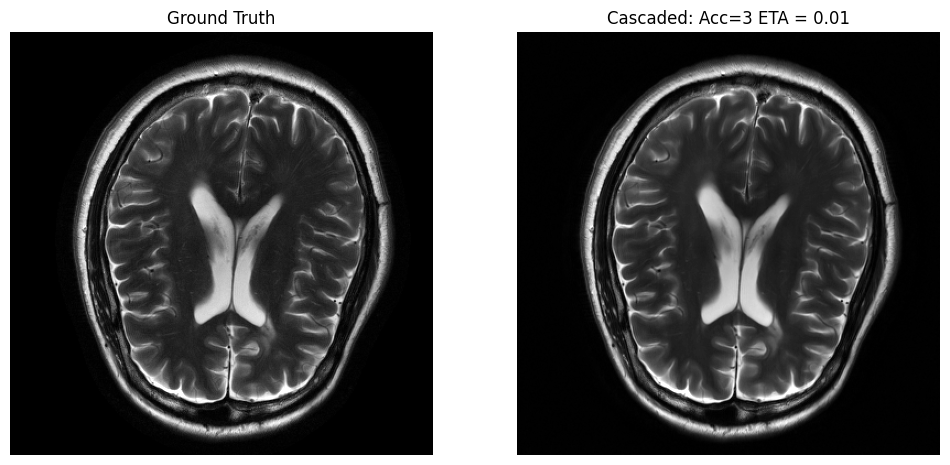

Saved summary figure.


In [73]:
plt.subplots(1, 2, figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(magnitude(x_gt), cmap='gray',vmax=0.8)
plt.title('Ground Truth', fontsize=12)
plt.axis('off')

plt.subplot(1,2, 2)
plt.imshow(x_ULA[0,0].abs().detach().cpu(), cmap='gray',vmax=0.8)
plt.title('Cascaded: Acc='+str(ACCELERATION)+ ' ETA = '+str(ETA), fontsize=12)
plt.axis('off')

plt.savefig(os.path.join(PROJECT_ROOT, f'outputs/alps_summary_Acc={ACCELERATION}_ETA={ETA}.png'))
plt.show()
print('Saved summary figure.')




In [58]:
# psnr_val_ula 

In [59]:
psnr_sample_ula = []
dc_ula = []
def DC(sample,measurement,A):
    dc_adj = A.forward(sample,tstCsm,tstMask)
    nll = (torch.sum((dc_adj-measurement).abs()**2,dim =(1,2,3)))
    #((A.forward(sample,tstCsm,tstMask) - measurement)**2).abs().sum()/ (2*opts.inference_std**2)
    return nll

for i in range(Nsamples):
    posterior = DC(torch.unsqueeze(x_stack_tensor_ULA[i], 0).to(device),b_hat,A)
    x_recULA_np = x_stack_tensor_ULA[i].abs().detach().cpu().squeeze().numpy()
    psnr = peak_signal_noise_ratio(target, x_recULA_np, data_range=target.max())
    psnr_sample_ula.append(psnr)
    dc_ula.append(posterior.detach().cpu().item())  

print(psnr_sample_ula)

fig, ax = plt.subplots(1, 5, figsize=(15, 3))

for i in range(min(5, Nsamples)):
    ax[i].imshow(((torch.unsqueeze(x_stack_tensor_ULA[i],0)[0,0]).abs().detach().cpu()),plt.cm.gray,vmax=0.85)
    ax[i].set_title(f"PSNR: {psnr_sample_ula[i]:.2f} dB\nDC: {dc_ula[i]:.4f}")
    ax[i].axis('off')

plt.tight_layout()
plt.show()

NameError: name 'b_hat' is not defined

In [ ]:
uncertainty_np = xvar_ULA.squeeze().cpu().numpy()
#uncertainty_np = (uncertainty_np - uncertainty_np.min()) / (uncertainty_np.max() - uncertainty_np.min() + 1e-8)




fig,ax = plt.subplots(1,3,figsize = (x.shape[0]*15,15))
ax[0].imshow(target, plt.cm.gray,vmax=0.85);ax[0].axis('off');ax[0].set_title('Original Image')
ax[1].imshow(xMMSE_ULA[0,0].detach().cpu(), plt.cm.gray,vmax=0.85);ax[1].axis('off');ax[1].set_title('MMSE')
ax[2].imshow(uncertainty_np);ax[2].axis('off');ax[2].set_title('Variance')



MALA

In [ ]:
def ALPS_old_stepsize_MALA(A, net, y, tstCsm,tstMask,class_labels,opts, isALPS=True, storeIntermediate=False):
    
    device = y.device
    t_steps = giveTsteps(opts.sigma_max,opts.sigma_min,opts.rho,opts.num_steps,device)
    
    Atb = A.adjoint(y,tstCsm)
    inference_std = opts.inference_std
    rhs=((1/(inference_std**2))*Atb)
    xtilde = A.init(Atb, rhs, inference_std, t_steps[0], tstCsm, tstMask)
    n = A.NoiseModulation(torch.randn_like(xtilde),tstMask,t_steps[0],inference_std)
    x = xtilde + n.detach() 
    
    
        
    acc_attempt_i = torch.zeros(len(t_steps), device=device, dtype=torch.long)
    acc_accept_i  = torch.zeros(len(t_steps), device=device, dtype=torch.long)
    rate_i = torch.zeros(len(t_steps), device=device, dtype=torch.float32)
    if storeIntermediate:
        xshape = list(x.shape)
        xshape[0] = len(t_steps+1)
        denoised = torch.zeros(xshape).cpu( )
        xdc = torch.zeros(xshape).cpu( )
        xsample = torch.zeros(xshape).cpu( )
        tsample = torch.zeros(len(t_steps+1)).cpu()
        posterior_energy=torch.zeros(len(t_steps+1)).cpu()

    for i in range(len(t_steps)):
        k=0 
        count = 0
        t = t_steps[i]
        # denoising
        _, score = giveScore(torch.cat((x.real,x.imag),1), net, t.reshape(-1, 1, 1, 1),precondition=True,class_labels=class_labels)
        score= score.detach()
        score = score[:,0,:,:] +1j* score[:,1,:,:]
        score = torch.unsqueeze(score,0)  
        d = (x-score).detach()
        # CG update
        xtilde = cg_quadratic(x,d,t,opts.inference_std,tstCsm,tstMask,y,A)

        
        while k<=opts.K-2 and count<=2*opts.K: # not doing it for the last iteration at scale t_i


            n = A.NoiseModulation(torch.randn_like(x), tstMask,t,opts.inference_std)
            x_new = x + ((opts.step_size**2)/2 *(xtilde-x)) + opts.step_size*n.detach()                                       

            # ---- MH acceptance ----
            log_alpha =  -cost_old(x_new,y,tstCsm,tstMask,t,net,A)+cost_old(x,y,tstCsm,tstMask,t,net,A)-(0.5*(1/opts.step_size**2)*delta_old(x,x_new,score,t,y,tstCsm,tstMask,A,net,opts))
            log_alpha = opts.beta*(log_alpha.detach())
            
            if torch.log(torch.rand((), device=device)) < log_alpha:
            
                #print(cost_old(x_new,y,t,net,A)- cost_old(x,y,t,net,A))
                x = x_new
                # denoising
                _, score = giveScore(torch.cat((x.real,x.imag),1), net, t.reshape(-1, 1, 1, 1),precondition=True,class_labels=class_labels)
                score= score.detach()
                score = score[:,0,:,:] +1j* score[:,1,:,:]
                score = torch.unsqueeze(score,0)
                d = (x-score).detach()
                # CG update
                xtilde = cg_quadratic(x,d,t,opts.inference_std,tstCsm,tstMask,y,A)
                k = k+ 1
            count = count+1
        #print(i,count)
        acc_attempt_i[i] =count 
        #print(acc_attempt_i[i])
        rate_i[i]= (k / acc_attempt_i[i].float()).item()
                
        

 

        if i < len(t_steps) - 1:
            t_next = t_steps[i + 1]
            _, score = giveScore(torch.cat((x.real,x.imag),1), net, t_next.reshape(-1, 1, 1, 1),precondition=True,class_labels=class_labels)
            score= score.detach()
            score = score[:,0,:,:] +1j* score[:,1,:,:]
            score = torch.unsqueeze(score,0) 
            d = (x-score).detach()
            # CG update
            x = cg_quadratic(x,d,t_next,opts.inference_std,tstCsm,tstMask,y,A)
            n = A.NoiseModulation(torch.randn_like(x),tstMask,t_steps[i+1],opts.inference_std)
            x = x+ opts.step_size*n.detach()
        else:
            _, score = giveScore(torch.cat((x.real,x.imag),1), net, t.reshape(-1, 1, 1, 1),precondition=True,class_labels=class_labels)
            score= score.detach()
            score = score[:,0,:,:] +1j* score[:,1,:,:]
            score = torch.unsqueeze(score,0)
            d = (x-score).detach()
            xtilde = cg_quadratic(x,d,t,opts.inference_std,tstCsm,tstMask,y,A)  
            x = xtilde
 
        
        if storeIntermediate:
            denoised[i] = d.abs().detach().cpu()
            xdc[i]= xtilde.abs().detach().cpu()
            posterior_energy[i]= cost_old(x, y, tstCsm,tstMask,t, net, A)
            xsample[i] = x.abs().detach().cpu()
            tsample[i] = t.detach().cpu()

    if storeIntermediate:
        return x, xsample,tsample,denoised,xdc,acc_attempt_i,rate_i,posterior_energy
    else:
        return x
    

def giveTsteps(sigma_max,sigma_min,rho,num_steps,device):
    """
    Annealing schedule
    """
    step_indices = torch.arange(num_steps, dtype=torch.float64, device=device)
    t_steps = (sigma_max ** (1 / rho) + step_indices / (num_steps - 1) * (sigma_min ** (1 / rho) - sigma_max ** (1 / rho))) ** rho
    return t_steps

def cost_old(sample,measurement,tstCsm,tstMask,scale,net,A):
    dc_adj = A.forward(sample,tstCsm,tstMask)
    nll = (torch.sum((dc_adj-measurement).abs()**2,dim =(1,2,3)))/ (2*opts.inference_std**2)

    nlp =giveScore(torch.cat((sample.real,sample.imag),1), net, scale.reshape(-1, 1, 1, 1),precondition=True,class_labels=class_labels)[0].detach()/(scale**2)
    
    return nll+nlp

def grad_C_old(sample,net,measurement,tstCsm,tstMask,scale,A, pre_compute_score=True,score=None):
    if pre_compute_score:
        score = score
    else:
        _, score = giveScore(torch.cat((sample.real,sample.imag),1), net, scale.reshape(-1, 1, 1, 1),precondition=True,class_labels=class_labels)
        score= score.detach()
        score = score[:,0,:,:] +1j* score[:,1,:,:]
        score = torch.unsqueeze(score,0)
    
    
    Atb = A.adjoint(measurement,tstCsm)
    grad_posterior = A.ATA(sample, tstCsm, tstMask)-Atb
    return grad_posterior/(opts.inference_std**2) +  score/scale**2
    


def quad_Binv_old(v, A, t):
    # v^T (A^T A / eta^2 + I / t^2) v  =  ||A v||^2 / eta^2 + ||v||^2 / t^2
    Av = A.forward(v,tstCsm,tstMask)
    return ((torch.sum((Av).abs()**2,dim =(1,2,3)))/ (opts.inference_std**2)) + (torch.sum((v).abs()**2,dim =(1,2,3)))/ (t**2)

def delta_old(old,new,score_old,scale,measurement,tstCsm,tstMask,A,net,opts):
    grad_old = grad_C_old(old,net,measurement,tstCsm,tstMask,scale,A, pre_compute_score=True,score=score_old)
    grad_new =  grad_C_old(new,net,measurement,tstCsm,tstMask, scale,A, pre_compute_score=False)
    precondition_new =A.dc(new, grad_new, tstCsm, tstMask,scale,opts.inference_std)
    precondition_old =A.dc(old, grad_old, tstCsm, tstMask,scale,opts.inference_std)
    v1 = old -new  + 0.5*opts.step_size**2*precondition_new
    v2 = new -old + 0.5*opts.step_size**2*precondition_old
   
    return quad_Binv_old(v1, A, scale) - quad_Binv_old(v2, A, scale)

In [ ]:
        
class Options:
    num_steps: int =  20
    sigma_max: float = 1
    sigma_min: float = 0.002
    rho: float = 7
    K: int = 5
    inference_std: float=0.006
    step_size: float = 0.05/math.sqrt(K)
    #0.05/math.sqrt(K)
    #0.01/math.sqrt(K)
    beta: int = 1

opts = Options() 
print("tune the ste-size according to acceleration!!!!")

In [ ]:
Nsamples = 5
x_stack_tensor_MALA = torch.empty(Nsamples, 1, 320, 320)
energy_MALA_all = torch.empty(Nsamples, opts.num_steps)
opts = Options()
torch.manual_seed(0)
start = time.perf_counter()
for i in range(Nsamples):
    print(i)
    
    
    
    
    x_MALA,xarray_MALA,tsample_MALA,denoised_MALA,xdc_MALA,acc,rate,energy_MALA = ALPS_old_stepsize_MALA(A, net, b_hat,tstCsm,tstMask,class_labels, opts, isALPS=True, storeIntermediate=True)
    energy_MALA_all[i] = energy_MALA.detach().cpu()
    x_stack_tensor_MALA[i] = (x_MALA*mask_csm).abs().detach().cpu()

end = time.perf_counter()
print(f"Cell took {end - start:0.4f} seconds")
  

xMMSE_MALA = torch.mean(x_stack_tensor_MALA, dim=0, keepdim=True)
xvar_MALA = torch.var(x_stack_tensor_MALA, dim=0, keepdim=True)
# Compute PSNR
target= np.squeeze(torch.abs(x).detach().cpu().numpy())
psnr_val_mala = (peak_signal_noise_ratio(target, np.squeeze(xMMSE_MALA.numpy()), data_range=target.max()))
#print(structural_similarity(target, np.squeeze(xMMSE_MALA.numpy()), data_range=target.max()))


In [ ]:
psnr_val_mala

In [ ]:
plt.stem(acc.detach().cpu().numpy())
plt.xlabel('Annealing step')
plt.ylabel('No. of attempts')

In [ ]:
plt.stem(rate.detach().cpu().numpy())
plt.xlabel('Annealing step')
plt.ylabel('Acceptance Rate')

In [ ]:
psnr_sample_mala = []
dc_mala = []


for i in range(Nsamples):
    posterior = DC(torch.unsqueeze(x_stack_tensor_MALA[i], 0).to(device),b_hat,A)
    x_recMALA_np = x_stack_tensor_MALA[i].abs().detach().cpu().squeeze().numpy()
    psnr = peak_signal_noise_ratio(target, x_recMALA_np, data_range=target.max())
    psnr_sample_mala.append(psnr)
    dc_mala.append(posterior.detach().cpu().item())  

print(psnr_sample_mala)

fig, ax = plt.subplots(1, 5, figsize=(15, 3))

for i in range(min(5, Nsamples)):
    ax[i].imshow(((torch.unsqueeze(x_stack_tensor_MALA[i],0)[0,0]).abs().detach().cpu()),plt.cm.gray,vmax=0.85)
    ax[i].set_title(f"PSNR: {psnr_sample_mala[i]:.2f} dB\nDC: {dc_mala[i]:.4f}")
    ax[i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
uncertainty_np = xvar_MALA.squeeze().cpu().numpy()
#uncertainty_np = (uncertainty_np - uncertainty_np.min()) / (uncertainty_np.max() - uncertainty_np.min() + 1e-8)




fig,ax = plt.subplots(1,3,figsize = (x.shape[0]*15,15))
ax[0].imshow(target, plt.cm.gray,vmax=0.85);ax[0].axis('off');ax[0].set_title('Original Image')
ax[1].imshow(xMMSE_MALA[0,0].detach().cpu(), plt.cm.gray,vmax=0.85);ax[1].axis('off');ax[1].set_title('MMSE')
ax[2].imshow(uncertainty_np);ax[2].axis('off');ax[2].set_title('Variance')



MAP

In [ ]:
class Options:
     num_steps: int =  20
     sigma_max: float = 1
     sigma_min: float = 0.01
     rho: float = 7
     K: int = 5
     inference_std: float=0.006
     L: int =2
    
opts = Options()     

In [ ]:
def mm_without_guidance(A, net, y, tstCsm,tstMask,class_labels,opts,target):
    device = y.device
    t_steps = giveTsteps(opts.sigma_max,opts.sigma_min,opts.rho,opts.num_steps,device)
    #initialization
    Atb = A.adjoint(y,tstCsm)
    inference_std = opts.inference_std
    rhs=((1/(inference_std**2))*Atb)
    x_init = A.init(Atb, rhs, inference_std, t_steps[0], tstCsm, tstMask)
    
    #A.sense_sol(Atb,Atb,100,tstCsm,tstMask)
    x_iter =x_init
    ratio = (opts.inference_std)**2
    lip_const=opts.L
    psnr_iter=[]
    obj=[]
    obj_scale =[]
    for i in range(len(t_steps)):
        for k in range(opts.K):
            t = t_steps[i]
            cost, score = giveScore(torch.cat((x_iter.real,x_iter.imag),1), net, t.reshape(-1, 1, 1, 1),precondition=True,class_labels=class_labels)
            score= score.detach()
            score = score[:,0,:,:] +1j* score[:,1,:,:]
            score = torch.unsqueeze(score,0)  
            rhs = Atb/ratio+ ((lip_const*x_iter)-(score) )/t**2
            x_iter = A.mm_inv(x_iter,rhs,tstCsm,tstMask,lip_const/t**2,1/ratio)
            #dc=A.forward(x_iter,tstCsm,tstMask)
            #psnr_iter.append(peak_signal_noise_ratio(target, np.squeeze(x_iter.abs().detach().cpu().numpy()), data_range=target.max()))
            #nll =(torch.sum((dc-y).abs()**2,dim =(1,2,3)))/(2*inference_std**2)
            #cost_obj,score_obj =  giveScore(torch.cat((x_iter.real,x_iter.imag),1), net, torch.tensor(opts.sigma_min).to(device).reshape(-1, 1, 1, 1),precondition=True,class_labels=class_labels)
            #cost_obj = cost_obj.detach()
            #score_obj = score_obj.detach()
            #del score_obj
            #obj.append(nll.detach().cpu().item()+(cost_obj/opts.sigma_min**2).detach().cpu().item())
            #obj_scale.append(nll.detach().cpu().item()+(cost/t**2).detach().cpu().item())
            
            del cost,score
            
            
    return x_iter,obj,obj_scale,psnr_iter

def giveTsteps(sigma_max,sigma_min,rho,num_steps,device):
    """
    Annealing schedule
    """
    step_indices = torch.arange(num_steps, dtype=torch.float64, device=device)
    t_steps = (sigma_max ** (1 / rho) + step_indices / (num_steps - 1) * (sigma_min ** (1 / rho) - sigma_max ** (1 / rho))) ** rho
    return t_steps

In [ ]:
# def MAP(A, net, y, tstCsm,tstMask,class_labels,opts,target):
    
    
    
#     device = y.device
#     t_steps = giveTsteps(opts.sigma_max,opts.sigma_min,opts.rho,opts.num_steps,device)
#     #initialization
#     Atb = A.adjoint(y,tstCsm)
#     inference_std = opts.inference_std
#     rhs=((1/(inference_std**2))*Atb)
#     xtilde = A.init(Atb, rhs, inference_std, t_steps[0], tstCsm, tstMask)
#     x = xtilde
    
    
    
#     obj=[]
#     obj_scale =[]
#     psnr_iter = []
#     for i in range(len(t_steps)):
        
#         for k in range(opts.K):
#             t = t_steps[i]
#             # denoising
#             cost, score = giveScore(torch.cat((x.real,x.imag),1), net, t.reshape(-1, 1, 1, 1),precondition=True,class_labels=class_labels)
#             score= score.detach()
#             score = score[:,0,:,:] +1j* score[:,1,:,:]
#             score = torch.unsqueeze(score,0)  
#             d = (x-score).detach()
#             # CG update
#             x = cg_quadratic(x,d,t,inference_std,tstCsm,tstMask,y,A)
#             dc=A.forward(x,tstCsm,tstMask)

#             psnr_iter.append(peak_signal_noise_ratio(target, np.squeeze(x.abs().detach().cpu().numpy()), data_range=target.max()))
#             nll =(torch.sum((dc-y).abs()**2,dim =(1,2,3)))/(2*inference_std**2)
#             cost_obj,score_obj =  giveScore(torch.cat((x.real,x.imag),1), net, torch.tensor(opts.sigma_min).to(device).reshape(-1, 1, 1, 1),precondition=True,class_labels=class_labels)
#             cost_obj = cost_obj.detach()
#             score_obj = score_obj.detach()
#             del score_obj
#             obj.append(nll.detach().cpu().item()+(cost_obj/opts.sigma_min**2).detach().cpu().item())
#             obj_scale.append(nll.detach().cpu().item()+(cost/t**2).detach().cpu().item())
            
            
#     return x,obj,obj_scale,psnr_iter
    

# def giveTsteps(sigma_max,sigma_min,rho,num_steps,device):
#     """
#     Annealing schedule
#     """
#     step_indices = torch.arange(num_steps, dtype=torch.float64, device=device)
#     t_steps = (sigma_max ** (1 / rho) + step_indices / (num_steps - 1) * (sigma_min ** (1 / rho) - sigma_max ** (1 / rho))) ** rho
#     return t_steps

In [ ]:
 

       

opts = Options()   
torch.manual_seed(0)
start = time.perf_counter()
x_MAP,objective,objective_scale,psnr_iter= mm_without_guidance(A, net, b_hat, tstCsm,tstMask,class_labels,opts,target)
end = time.perf_counter()
print(f"Cell took {end - start:0.4f} seconds")
# Compute PSNR

xMAP_np = (x_MAP*mask_csm).abs().detach().cpu().numpy()
psnr_val_map = peak_signal_noise_ratio(target, np.squeeze(xMAP_np), data_range=target.max())


In [ ]:
plt.plot(psnr_iter)

DAPS

In [ ]:
import pickle
network_pkl = "./models/teacher_model/Full_fastmri_score_model.pkl"
with dnnlib.util.open_url(network_pkl) as f:
    net = pickle.load(f)['ema'].to(device)
net.eval()



In [ ]:
def edm_sampler(
    net, latents, class_labels=None, randn_like=torch.randn_like,
    num_steps=18, sigma_min=0.002, sigma_max=80, rho=7,
    S_churn=0, S_min=0, S_max=float('inf'), S_noise=1,
):
    # Adjust noise levels based on what's supported by the network.
    sigma_min = max(sigma_min, net.sigma_min)
    sigma_max = min(sigma_max, net.sigma_max)

    # Time step discretization.
    if num_steps>1:
        step_indices = torch.arange(num_steps, dtype=torch.float64, device=latents.device)
        t_steps = (sigma_max ** (1 / rho) + step_indices / (num_steps - 1) * (sigma_min ** (1 / rho) - sigma_max ** (1 / rho))) ** rho
        t_steps = torch.cat([(t_steps), torch.zeros_like(t_steps[:1])]) # t_N = 0
    else:
        t_steps = torch.tensor([sigma_max], dtype=torch.float64, device=latents.device)
        t_steps = torch.cat([(t_steps), torch.zeros_like(t_steps[:1])])
    

    # Main sampling loop.
    #("changed the init")
    x_next = latents.to(torch.float64) 
    #* t_steps[0]
    for i, (t_cur, t_next) in enumerate(zip(t_steps[:-1], t_steps[1:])): # 0, ..., N-1
        
        x_cur = x_next

        # Increase noise temporarily.
        gamma = min(S_churn / num_steps, np.sqrt(2) - 1) if S_min <= t_cur <= S_max else 0
        t_hat = net.round_sigma(t_cur + gamma * t_cur)
        x_hat = x_cur + (t_hat ** 2 - t_cur ** 2).sqrt() * S_noise * randn_like(x_cur)

        # Euler step.
        denoised = net(x_hat, t_hat, class_labels).to(torch.float64)
        d_cur = (x_hat - denoised) / t_hat
        x_next = x_hat + (t_next - t_hat) * d_cur

    return x_next



In [ ]:
def Langevin_update(posterior_latents, image, A, tstCsm,tstMask,measurement, noise_level, step_size, measurement_noise, langevin_steps):
    


    for i in range(langevin_steps):
        grad_log_prior = - (posterior_latents - image)/noise_level**2
        error = A.forward(posterior_latents,tstCsm,tstMask)-measurement
        grad_measurement = -( A.adjoint(error,tstCsm))/measurement_noise
        posterior_latents = posterior_latents + step_size*(grad_measurement+grad_log_prior)+ math.sqrt(2*step_size)*torch.randn_like(posterior_latents)

    return posterior_latents

In [ ]:
def Daps(A, net, y, opts, storeIntermediate=False):
    
    t_steps = giveTsteps(opts.sigma_max,opts.sigma_min,opts.rho,opts.num_steps,device)
    latents = torch.randn(1, 1, 320, 320, device=device)+1j*torch.randn(1, 1, 320, 320, device=device)
    x = latents*t_steps[0]
    if storeIntermediate:
        xshape = list(x.shape)
        xshape[0] = len(t_steps+1)
        xsample = torch.zeros(xshape).cpu( )

    for i in range(opts.num_steps):
        t = t_steps[i]
        # solving ODE
        
        d = edm_sampler(net, latents = torch.cat((x.real,x.imag),1), class_labels=opts.class_labels,num_steps=opts.ode_steps
                                  ,sigma_max= t,sigma_min=opts.sigma_min,rho = opts.ode_rho)
        d = d.detach()
        d = d[:,0,:,:] +1j* d[:,1,:,:]
        d = torch.unsqueeze(d,0)

        
       
        d = d.detach()
        

        #langevin update 
        #step_size = compute_eta_t(i, opts.eta_0, opts.delta,opts.num_steps-1)
        step_size = compute_eta_t(opts.num_steps - 1 - i, opts.eta_0, opts.delta, opts.num_steps - 1)
        updated_posterior = Langevin_update(d, d, A, tstCsm,tstMask,y, t, step_size, (opts.inference_std)**2, opts.langevin_steps) 
        
        
           

             
        x = updated_posterior + t_steps[i+1]*torch.randn_like(updated_posterior)
            
        if storeIntermediate:
            xsample[i] = x.abs().detach().cpu()

    if storeIntermediate:
        return x, xsample
    else:
        return x
    

def giveTsteps(sigma_max,sigma_min,rho,num_steps,device):
    step_indices = torch.arange(num_steps, dtype=torch.float64, device=device)
    t_steps = (sigma_max ** (1 / rho) + step_indices / (num_steps - 1) * (sigma_min ** (1 / rho) - sigma_max ** (1 / rho))) ** rho
    t_steps = torch.cat([(t_steps), torch.zeros_like(t_steps[:1])])
    return t_steps

def compute_eta_t(t, eta_0, delta,T):
    eta_t = eta_0 * (delta + (t / T) * (1.0 - delta))
    return eta_t

In [ ]:
# DAPS Reconstruction
from skimage.metrics import peak_signal_noise_ratio
@dataclass
class Options:
    num_steps: int = 200
    sigma_max: float = 100
    sigma_min: float = 0.1
    rho: float = 7
    ode_steps: int = 5
    ode_rho: float=7
    ode_sigma_min: float = 0.02

    eta_0: float = 1e-4
    delta: float = 1e-2
    langevin_steps: int= 100 

    inference_std: float=0.01  
    class_labels = class_labels
opts = Options()


Nsamples = 5
x_stack_tensor_Daps = torch.empty(Nsamples, 1, 320, 320)
torch.manual_seed(0)
start = time.perf_counter()
for i in range(Nsamples):
    print(i)
    x_Daps  = Daps(A, net, b_hat, opts, storeIntermediate=False)
    x_stack_tensor_Daps[i] = (x_Daps*mask_csm).abs().detach().cpu()
    
end = time.perf_counter()
print(f"Cell took {end - start:0.4f} seconds")
xMMSE_Daps = torch.mean(x_stack_tensor_Daps, dim=0, keepdim=True)
xvar_Daps = torch.var(x_stack_tensor_Daps, dim=0, keepdim=True)
# # Compute PSNR

psnr_val_Daps = peak_signal_noise_ratio(target, np.squeeze(xMMSE_Daps.numpy()), data_range=target.max())



In [ ]:
peak_signal_noise_ratio(target, np.squeeze(xMMSE_Daps.numpy()), data_range=target.max())

In [ ]:
psnr_sample_daps = []
dc_daps = []


for i in range(Nsamples):
    posterior = DC(torch.unsqueeze(x_stack_tensor_Daps[i], 0).to(device),b_hat,A)
    x_recDaps_np = x_stack_tensor_Daps[i].abs().detach().cpu().squeeze().numpy()
    psnr = peak_signal_noise_ratio(target, x_recDaps_np, data_range=target.max())
    psnr_sample_daps.append(psnr)
    dc_daps.append(posterior.detach().cpu().item())  

print(psnr_sample_daps)

fig, ax = plt.subplots(1, 5, figsize=(15, 3))

for i in range(min(5, Nsamples)):
    ax[i].imshow(((torch.unsqueeze(x_stack_tensor_Daps[i],0)[0,0]).abs().detach().cpu()),plt.cm.gray,vmax=0.85)
    ax[i].set_title(f"PSNR: {psnr_sample_daps[i]:.2f} dB\nDC: {dc_daps[i]:.4f}")
    ax[i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
uncertainty_np = xvar_Daps.squeeze().cpu().numpy()
#uncertainty_np = (uncertainty_np - uncertainty_np.min()) / (uncertainty_np.max() - uncertainty_np.min() + 1e-8)




fig,ax = plt.subplots(1,3,figsize = (x.shape[0]*15,15))
ax[0].imshow(target, plt.cm.gray,vmax=0.85);ax[0].axis('off');ax[0].set_title('Original Image')
ax[1].imshow(xMMSE_Daps[0,0].detach().cpu(), plt.cm.gray,vmax=0.85);ax[1].axis('off');ax[1].set_title('MMSE')
ax[2].imshow(uncertainty_np);ax[2].axis('off');ax[2].set_title('Variance')



DPS

In [ ]:
num_steps = 300
sigma_min = .002
sigma_max = 5
rho = 7


# class_labels = None
# if net.label_dim:
#     class_labels = torch.eye(net.label_dim, device=device)[0]
#     #class_labels = torch.eye(net.label_dim, device=device)[torch.randint(net.label_dim, size=[1], device=device)]
    
# - noise levels
step_indices = torch.arange(num_steps, dtype=torch.float64, device=device)
t_steps = (sigma_max ** (1 / rho) + step_indices / (num_steps - 1) * (sigma_min ** (1 / rho) - sigma_max ** (1 / rho))) ** rho
t_steps = torch.cat([net.round_sigma(t_steps), torch.zeros_like(t_steps[:1])]) # t_N = 0

In [ ]:
import tqdm
def DPS(net, y, sens, mask,opts):
    t_steps = giveTsteps(opts.sigma_max,opts.sigma_min,opts.rho,opts.num_steps,device)
    latents = torch.randn([1, net.img_channels, 320, 320], device=device)
    t_next = t_steps[0]
    x_next = latents.to(torch.float64) * t_steps[0]
    for i, (t_cur, t_next) in tqdm.tqdm(enumerate(zip(t_steps[:-1], t_steps[1:])),total=len(t_steps[1:])): 
        x_cur = x_next
        x_hat = x_cur
        x_hat = x_hat.requires_grad_() 
        ## - prior update
        denoised = net(x_hat,t_cur,opts.class_labels).to(torch.float64)
        d_cur = (x_hat - denoised)/t_cur
        x_next = x_hat + (t_next - t_cur) * d_cur
        # - l2 update
        denoised_complex = torch.view_as_complex(denoised.permute(0,2,3,1).contiguous())#denoised[0,0,...] + 1j*denoised[0,1,...]
        Ax = forward_without_ref(denoised_complex,sens,mask)    
        DC_term = y - Ax
        DC_term = torch.view_as_real(DC_term)
        sse = 0.5*torch.norm(DC_term)**2
        meas_grad = torch.autograd.grad(outputs=sse, inputs=x_hat)[0]
        meas_grad = meas_grad / torch.sqrt(sse)
        likelihood_step_size = 0.95
        x_next = x_next - (likelihood_step_size) * meas_grad    
        x_next = x_next.detach()   # to free the computational graph after auto grad is called
        x_hat = x_hat.requires_grad_(False)
        x_next_complex = torch.complex(x_next[0,0,...], x_next[0,1,...])#denoised[0,0,...] + 1j*denoised[0,1,...]
        x_next_clean = adjoint(forward_without_ref(x_next_complex, sens, torch.ones_like(mask)), sens, torch.ones_like(mask))
        x_next_clean = torch.permute(torch.view_as_real(x_next_clean), (0,3,1,2))#[None,...]
        images = x_next_clean 
        images_complex = (torch.complex(images[:,0,...], images[:,1,...])).squeeze()

    return images_complex

def giveTsteps(sigma_max,sigma_min,rho,num_steps,device):
    step_indices = torch.arange(num_steps, dtype=torch.float64, device=device)
    t_steps = (sigma_max ** (1 / rho) + step_indices / (num_steps - 1) * (sigma_min ** (1 / rho) - sigma_max ** (1 / rho))) ** rho
    t_steps = torch.cat([(t_steps), torch.zeros_like(t_steps[:1])])
    return t_steps


#forward = lambda x :forward_without_ref(x, sens, mask)

import torch.fft as torch_fft
def forward_without_ref(x, sens, mask):
    x = x[None,...]*sens
    x = torch_fft.ifftshift(x, dim=(-2, -1))
    x = torch_fft.fft2(x, dim=(-2, -1), norm='ortho')
    x = torch_fft.fftshift(x, dim=(-2, -1))
    y = x*mask
    return y[None,...]

def forward_with_ref(x, sens, mask, mask_ref):
    x = x[None,...]*sens
    x = torch_fft.ifftshift(x, dim=(-2, -1))
    x = torch_fft.fft2(x, dim=(-2, -1), norm='ortho')
    x = torch_fft.fftshift(x, dim=(-2, -1))
    return torch.stack((x*mask,x*mask_ref), dim=0)

def adjoint(x, sens, mask):
    x = x*mask
    x = torch_fft.ifftshift(x, dim=(-2, -1))
    x = torch_fft.ifft2(x, dim=(-2, -1), norm='ortho')
    x = torch_fft.fftshift(x, dim=(-2, -1))
    x = torch.sum(x*torch.conj(sens), axis=1)
    return x

def NRMSELoss(X, Y):
    # X = GT image
    # Y = output image
    error_norm = torch.square(torch.norm(X - Y))
    self_norm  = torch.square(torch.norm(X))
    return torch.sqrt(error_norm / self_norm)

In [ ]:
@dataclass
class Options:
    num_steps = 300
    sigma_min = 0.002
    sigma_max = 5
    rho = 7
    class_labels = class_labels
opts = Options()

In [ ]:
Nsamples =5
x_stack_tensor_Dps = torch.empty(Nsamples, 1, 320, 320)
torch.manual_seed(0)
start = time.perf_counter()
for i in range(Nsamples):
    print(i)
    x_DPS  = DPS(net, torch.squeeze(torch.squeeze(b_hat,0),0), torch.squeeze(torch.squeeze(tstCsm,0),0), torch.squeeze(tstMask,0), opts)
    x_stack_tensor_Dps[i] = (x_DPS*mask_csm).abs().detach().cpu()
end = time.perf_counter()
print(f"Cell took {end - start:0.4f} seconds")


xMMSE_Dps = torch.mean(x_stack_tensor_Dps, dim=0, keepdim=True)
xvar_Dps = torch.var(x_stack_tensor_Dps, dim=0, keepdim=True)
# # Compute PSNR

psnr_val_Dps = peak_signal_noise_ratio(target, np.squeeze(xMMSE_Dps.numpy()), data_range=target.max())





In [ ]:
psnr_sample_dps = []
dc_dps = []
def DC(sample,measurement,A):
    dc_adj = A.forward(sample,tstCsm,tstMask)
    nll = (torch.sum((dc_adj-measurement).abs()**2,dim =(1,2,3)))
    #((A.forward(sample,tstCsm,tstMask) - measurement)**2).abs().sum()/ (2*opts.inference_std**2)
    return nll

for i in range(Nsamples):
    posterior = DC(torch.unsqueeze(x_stack_tensor_Dps[i], 0).to(device),b_hat,A)
    x_recDps_np = x_stack_tensor_Dps[i].abs().detach().cpu().squeeze().numpy()
    psnr = peak_signal_noise_ratio(target, x_recDps_np, data_range=target.max())
    psnr_sample_dps.append(psnr)
    dc_dps.append(posterior.detach().cpu().item())  

print(psnr_sample_dps)

fig, ax = plt.subplots(1, 5, figsize=(15, 3))

for i in range(min(5, Nsamples)):
    ax[i].imshow(((torch.unsqueeze(x_stack_tensor_Dps[i],0)[0,0]).abs().detach().cpu()),plt.cm.gray,vmax=0.85)
    ax[i].set_title(f"PSNR: {psnr_sample_dps[i]:.2f} dB\nDC: {dc_dps[i]:.4f}")
    ax[i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
uncertainty_np = xvar_Dps.squeeze().cpu().numpy()
#uncertainty_np = (uncertainty_np - uncertainty_np.min()) / (uncertainty_np.max() - uncertainty_np.min() + 1e-8)




fig,ax = plt.subplots(1,3,figsize = (x.shape[0]*15,15))
ax[0].imshow(target, plt.cm.gray,vmax=0.85);ax[0].axis('off');ax[0].set_title('Original Image')
ax[1].imshow(xMMSE_Dps[0,0].detach().cpu(), plt.cm.gray,vmax=0.85);ax[1].axis('off');ax[1].set_title('MMSE')
ax[2].imshow(uncertainty_np);ax[2].axis('off');ax[2].set_title('Variance')



PnP-ISTA

In [ ]:
def pnp_ista(A,net,y,tstCsm,tstMask,opts):
    Atb = A.adjoint(y,tstCsm).detach()
    
    #initialization
    s=Atb
    
    
    
    with torch.no_grad():
        for i in range(opts.num_steps):
            grad = (A.ATA(s, tstCsm, tstMask)-Atb)/opts.inference_std**2
            
            z = s - (opts.step_size*grad)
            s = net(torch.cat((z.real,z.imag),1), torch.tensor(opts.sigma).to(device).reshape(-1, 1, 1, 1),class_labels=opts.class_labels)
            s = s.detach()
            s = s[:,0,:,:] +1j* s[:,1,:,:]
            s = torch.unsqueeze(s,0)
            

        
      
            
        
                
            
    return s

In [ ]:
@dataclass
class Options:
    num_steps = 300
    sigma = 0.1
    step_size = 0.005
    class_labels = class_labels
    inference_std: float=0.1  
opts = Options()

In [ ]:
start = time.perf_counter()
ista = pnp_ista(A,net,b_hat,tstCsm,tstMask,opts)
end = time.perf_counter()
print(f"Cell took {end - start:0.4f} seconds")
xista_np = (ista*mask_csm).abs().detach().cpu().numpy()
psnr_val_ista = peak_signal_noise_ratio(target, np.squeeze(xista_np), data_range=target.max())


In [ ]:
def Langevin_update(net, A, tstCsm,tstMask,measurement):
    device = measurement.device
    noise_level = torch.tensor(opts.noise_level).to(device)
    measurement_noise =opts.inference_std**2
    posterior_latents =  (torch.randn([1, 1, 320, 320], device=device)).clamp(opts.clamp_min, opts.clamp_max)+ 1j*torch.randn([1, 1, 320, 320], device=device).clamp(opts.clamp_min, opts.clamp_max)
    


    for i in range(opts.num_steps):
        denoised_image =  net(torch.cat((posterior_latents.real,posterior_latents.imag),1), torch.tensor(opts.noise_level).to(device).reshape(-1, 1, 1, 1),class_labels=opts.class_labels)
        denoised_image = denoised_image.detach()
        denoised_image = denoised_image[:,0,:,:] +1j* denoised_image[:,1,:,:]
        denoised_image = torch.unsqueeze(denoised_image,0)
        grad_log_prior = - (posterior_latents - denoised_image)/noise_level**2
        error = A.forward(posterior_latents,tstCsm,tstMask)-measurement
        grad_measurement = -( A.adjoint(error,tstCsm))/measurement_noise
        posterior_latents = posterior_latents + opts.step_size*(grad_measurement+grad_log_prior)+ math.sqrt(2*opts.step_size)*torch.randn_like(posterior_latents)
        posterior_latents.real = posterior_latents.real.clamp(opts.clamp_min, opts.clamp_max)
        posterior_latents.imag = posterior_latents.imag.clamp(opts.clamp_min, opts.clamp_max)

    return posterior_latents

In [ ]:
@dataclass
class Options:
    num_steps =  5000
    class_labels = class_labels
    noise_level = 0.1
    clamp_min = -1
    clamp_max = 1
    step_size = 1e-3
    inference_std: float=0.1  
opts = Options()

In [ ]:
Nsamples = 5
x_stack_tensor_PnPULA = torch.empty(Nsamples, 1, 320, 320)
torch.manual_seed(0)
start = time.perf_counter()
for i in range(Nsamples):
    print(i)
    x_pnpula  = Langevin_update(net, A,tstCsm,tstMask,b_hat)
    x_stack_tensor_PnPULA[i] = (x_pnpula*mask_csm).abs().detach().cpu()
end = time.perf_counter()
print(f"Cell took {end - start:0.4f} seconds")

xMMSE_pnpula = torch.mean(x_stack_tensor_PnPULA, dim=0, keepdim=True)
xvar_pnpula = torch.var(x_stack_tensor_PnPULA, dim=0, keepdim=True)


psnr_val_PnPULA= peak_signal_noise_ratio(target, np.squeeze(xMMSE_pnpula.numpy()), data_range=target.max())


In [ ]:
uncertainty_np = xvar_pnpula.squeeze().cpu().numpy()
#uncertainty_np = (uncertainty_np - uncertainty_np.min()) / (uncertainty_np.max() - uncertainty_np.min() + 1e-8)




fig,ax = plt.subplots(1,3,figsize = (x.shape[0]*15,15))
ax[0].imshow(target, plt.cm.gray,vmax=0.85);ax[0].axis('off');ax[0].set_title('Original Image')
ax[1].imshow(xMMSE_pnpula[0,0].detach().cpu(), plt.cm.gray,vmax=0.85);ax[1].axis('off');ax[1].set_title('MMSE')
ax[2].imshow(uncertainty_np);ax[2].axis('off');ax[2].set_title('Variance')

In [ ]:
psnr_sample_PnPULA = []
dc_PnPULA = []


for i in range(Nsamples):
    posterior = DC(torch.unsqueeze(x_stack_tensor_PnPULA[i], 0).to(device),b_hat,A)
    x_recPnPULA_np = x_stack_tensor_PnPULA[i].abs().detach().cpu().squeeze().numpy()
    psnr = peak_signal_noise_ratio(target, x_recPnPULA_np, data_range=target.max())
    psnr_sample_PnPULA.append(psnr)
    dc_PnPULA.append(posterior.detach().cpu().item())  



fig, ax = plt.subplots(1, 5, figsize=(15, 3))

for i in range(min(5, Nsamples)):
    ax[i].imshow(((torch.unsqueeze(x_stack_tensor_PnPULA[i],0)[0,0]).abs().detach().cpu()),plt.cm.gray,vmax=0.85)
    ax[i].set_title(f"PSNR: {psnr_sample_PnPULA[i]:.2f} dB\nDC: {dc_PnPULA[i]:.4f}")
    ax[i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
target- (x_MAP*mask_csm)[0,0].abs().detach().cpu().numpy()

In [ ]:
disp = [tstMask[0,0].abs().detach().cpu(),target, xMMSE_ULA[0,0],xMMSE_MALA[0,0],(x_MAP*mask_csm)[0,0].abs().detach().cpu(),xMMSE_Daps[0,0],xMMSE_Dps[0,0],xMMSE_pnpula[0,0],(ista*mask_csm)[0,0].abs().detach().cpu()]
labels =["Mask","Reference","ALPS-ULA","ALPS-MALA","ALPS-MAP","DAPS","DPS","PnP-ULA", "PnP-ISTA"]
error = [target- xMMSE_ULA[0,0].cpu().numpy(),target- xMMSE_MALA[0,0].cpu().numpy(),target- (x_MAP*mask_csm)[0,0].abs().detach().cpu().numpy(),target- xMMSE_Daps[0,0].cpu().numpy(),target- xMMSE_Dps[0,0].cpu().numpy(),target- xMMSE_pnpula[0,0].cpu().numpy(),target- (ista*mask_csm)[0,0].abs().detach().cpu().numpy() ]
psnrs= [psnr_val_ula,psnr_val_mala,psnr_val_map,psnr_val_Daps,psnr_val_Dps,psnr_val_PnPULA,psnr_val_ista  ]
tcolor =['black','black','black','black','black','black','black','black','black']

In [ ]:
from matplotlib.gridspec import GridSpec
import matplotlib.patches as patches
zoomPoint = (90,80)#(90,150)
zoomSize = (120, 120)

fig = plt.figure(figsize=(25,9))
n = len(disp)
gs = GridSpec(nrows=3, ncols=max(2,n), figure=fig, top=1, bottom=0, wspace=0.01, hspace=0.01, left=0, right=1)

for i in range(n):
    ax0 = fig.add_subplot(gs[0, i])
    #ax0.imshow(disp[i],plt.cm.gray,vmax =0.8)
    ax0.imshow(torch.rot90(torch.rot90(torch.tensor(disp[i]))), vmax=0.8,cmap=plt.cm.gray)
    ax0.axis('off')
    if i==0 or i==1:
        titleObj = ax0.set_title(f"{labels[i]}",fontsize=19)
        ax0.axis('off')
    else:
        titleObj = ax0.set_title(f"{labels[i]}"'\n(PSNR={:.2f} dB)'.format(psnrs[i-2]),color=tcolor[i],fontsize=19)
        ax0.axis('off')
    if i>0:
        rect = patches.Rectangle(zoomPoint, zoomSize[0], zoomSize[1], linewidth=1, edgecolor='r', facecolor='none')
        ax0.add_patch(rect)
        ax1 = fig.add_subplot(gs[1, i])
        ax1.imshow(torch.rot90(torch.rot90(torch.tensor(disp[i])))[zoomPoint[1]:zoomPoint[1]+zoomSize[1], zoomPoint[0]:zoomPoint[0]+zoomSize[0]], vmax=0.8, cmap=plt.cm.gray)
        ax1.axis('off')
       
    if i>1:
        ax2 = fig.add_subplot(gs[2, i])
        ax2.imshow(torch.rot90(torch.rot90(torch.tensor(error[i-2]))).abs(), vmax=0.1)#0.03
        ax2.axis('off')
#fig.savefig('./paper_results/MRI_4x1D_newmodel_T2_error'+'.pdf', format='pdf',dpi=300,bbox_inches='tight')   

In [ ]:
best_idx_ula = np.argmax(psnr_sample_ula)
best_idx_mala = np.argmax(psnr_sample_mala)
best_idx_daps = np.argmax(psnr_sample_daps) 
best_idx_dps = np.argmax(psnr_sample_dps) 
best_idx_pnpula = np.argmax(psnr_sample_PnPULA) 

In [ ]:
disp = [tstMask[0,0].abs().detach().cpu(),target,x_stack_tensor_ULA[best_idx_ula],x_stack_tensor_MALA[best_idx_mala],x_stack_tensor_Daps[best_idx_daps],x_stack_tensor_Dps[best_idx_dps],x_stack_tensor_PnPULA[best_idx_pnpula]]

error = [target-torch.squeeze(x_stack_tensor_ULA[best_idx_ula],0).cpu().numpy(),target-torch.squeeze(x_stack_tensor_MALA[best_idx_mala],0).cpu().numpy(),target-torch.squeeze(x_stack_tensor_Daps[best_idx_daps],0).cpu().numpy(),target-torch.squeeze(x_stack_tensor_Dps[best_idx_dps],0).cpu().numpy(),target-torch.squeeze(x_stack_tensor_PnPULA[best_idx_pnpula],0).cpu().numpy()]

labels =["Measurement","Reference","ALPS-ULA","ALPS-MALA","DAPS","DPS","PnP-ULA"]
psnrs = [psnr_sample_ula[best_idx_ula],psnr_sample_mala[best_idx_mala],psnr_sample_daps[best_idx_daps],psnr_sample_dps[best_idx_dps],psnr_sample_PnPULA[best_idx_pnpula]  ]
tcolor =['black','black','black','black','black','black','black','black','black']

In [ ]:
target-torch.squeeze(x_stack_tensor_ULA[best_idx_ula],0).cpu().numpy()

In [ ]:
from matplotlib.gridspec import GridSpec
import matplotlib.patches as patches
zoomPoint = (90,80)#(90,150)
zoomSize = (120, 120)

fig = plt.figure(figsize=(21,9))
n = len(disp)
gs = GridSpec(nrows=3, ncols=max(2,n), figure=fig, top=1, bottom=0, wspace=0.01, hspace=0.01, left=0, right=1)

for i in range(n):
    ax0 = fig.add_subplot(gs[0, i])
    #ax0.imshow(disp[i],plt.cm.gray,vmax =0.8)
    if i==0 or i==1:
        ax0.imshow(torch.rot90(torch.rot90(torch.tensor(disp[i]))), vmax=0.8,cmap=plt.cm.gray)
        ax0.axis('off')
        titleObj = ax0.set_title(f"{labels[i]}",fontsize=19)
        ax0.axis('off')
    else:
        titleObj = ax0.set_title(f"{labels[i]}"'\n(PSNR={:.2f} dB)'.format(psnrs[i-2]),color=tcolor[i],fontsize=19)
        ax0.imshow(torch.rot90(torch.rot90(torch.unsqueeze(disp[i],0)[0,0])), vmax=0.8,cmap=plt.cm.gray)
        
        ax0.axis('off')
    if i==1:
        rect = patches.Rectangle(zoomPoint, zoomSize[0], zoomSize[1], linewidth=1, edgecolor='r', facecolor='none')
        ax0.add_patch(rect)
        ax1 = fig.add_subplot(gs[1, i])
        ax1.imshow(torch.rot90(torch.rot90(torch.tensor(disp[i])))[zoomPoint[1]:zoomPoint[1]+zoomSize[1], zoomPoint[0]:zoomPoint[0]+zoomSize[0]], vmax=0.8,cmap=plt.cm.gray)
        ax1.axis('off')
    if i>1:
        rect = patches.Rectangle(zoomPoint, zoomSize[0], zoomSize[1], linewidth=1, edgecolor='r', facecolor='none')
        ax0.add_patch(rect)
        
        ax1 = fig.add_subplot(gs[1, i])
        ax1.imshow(torch.rot90(torch.rot90(torch.unsqueeze(disp[i],0)[0,0]))[zoomPoint[1]:zoomPoint[1]+zoomSize[1], zoomPoint[0]:zoomPoint[0]+zoomSize[0]], vmax=0.8, cmap=plt.cm.gray)
        ax1.axis('off')
       
    if i>1:
        ax2 = fig.add_subplot(gs[2, i])
        ax2.imshow(torch.rot90(torch.rot90(torch.tensor(error[i-2]))).abs(), vmax=0.1)#0.03
        ax2.axis('off')
#fig.savefig('./paper_results/1sample_method_MRI_4x1D_newmodel_T2'+'.pdf', format='pdf',dpi=300,bbox_inches='tight')   

In [ ]:

uncertainty_ULA_np = xvar_ULA.squeeze().cpu().numpy()
print(uncertainty_ULA_np.max(),uncertainty_ULA_np.min())



uncertainty_MALA_np = xvar_MALA.squeeze().cpu().numpy()
print(uncertainty_MALA_np.max(),uncertainty_MALA_np.min())


uncertainty_Daps = xvar_Daps.mean(dim=1, keepdim=True)
uncertainty_Daps_np = xvar_Daps.squeeze().cpu().numpy()
print(uncertainty_Daps_np.max(),uncertainty_Daps_np.min())



uncertainty_Dps_np =xvar_Dps.squeeze().cpu().numpy()
print(uncertainty_Dps_np.max(),uncertainty_Dps_np.min())


uncertainty_PnPULA_np = xvar_pnpula.squeeze().cpu().numpy()
print(uncertainty_PnPULA_np.max(),uncertainty_PnPULA_np.min())


vmax =0.0015

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import torch
import os

# 5 sample images + 1 uncertainty image per method
disp_rows = [
    [x_stack_tensor_ULA[0], x_stack_tensor_ULA[1], x_stack_tensor_ULA[2], x_stack_tensor_ULA[3], x_stack_tensor_ULA[4], uncertainty_ULA_np],
    [x_stack_tensor_MALA[0], x_stack_tensor_MALA[1], x_stack_tensor_MALA[2], x_stack_tensor_MALA[3], x_stack_tensor_MALA[4], uncertainty_MALA_np],
    [x_stack_tensor_Daps[0], x_stack_tensor_Daps[1], x_stack_tensor_Daps[2], x_stack_tensor_Daps[3], x_stack_tensor_Daps[4], uncertainty_Daps_np],
    [x_stack_tensor_Dps[0], x_stack_tensor_Dps[1], x_stack_tensor_Dps[2], x_stack_tensor_Dps[3], x_stack_tensor_Dps[4], uncertainty_Dps_np],
    [x_stack_tensor_PnPULA[0], x_stack_tensor_PnPULA[1], x_stack_tensor_PnPULA[2], x_stack_tensor_PnPULA[3], x_stack_tensor_PnPULA[4], uncertainty_PnPULA_np],
]

psnr_rows = [
    [psnr_sample_ula[0], psnr_sample_ula[1], psnr_sample_ula[2], psnr_sample_ula[3], psnr_sample_ula[4], None],
    [psnr_sample_mala[0], psnr_sample_mala[1], psnr_sample_mala[2], psnr_sample_mala[3], psnr_sample_mala[4], None],
    [psnr_sample_daps[0], psnr_sample_daps[1], psnr_sample_daps[2], psnr_sample_daps[3], psnr_sample_daps[4], None],
    [psnr_sample_dps[0], psnr_sample_dps[1], psnr_sample_dps[2], psnr_sample_dps[3], psnr_sample_dps[4], None],
    [psnr_sample_PnPULA[0], psnr_sample_PnPULA[1], psnr_sample_PnPULA[2], psnr_sample_PnPULA[3], psnr_sample_PnPULA[4], None],
]

dc_rows = [
    [dc_ula[0], dc_ula[1], dc_ula[2], dc_ula[3], dc_ula[4], None],
    [dc_mala[0], dc_mala[1], dc_mala[2], dc_mala[3], dc_mala[4], None],
    [dc_daps[0], dc_daps[1], dc_daps[2], dc_daps[3], dc_daps[4], None],
    [dc_dps[0], dc_dps[1], dc_dps[2], dc_dps[3], dc_dps[4], None],
    [dc_PnPULA[0], dc_PnPULA[1], dc_PnPULA[2], dc_PnPULA[3], dc_PnPULA[4], None],
]

row_labels = ["ULA", "MALA", "DAPS", "DPS", "PnPULA"]




fig = plt.figure(figsize=(20, 16))
gs = GridSpec(
    nrows=5,
    ncols=6,
    figure=fig,
    wspace=0.05,
    hspace=0.25,
    left=0.03,
    right=0.99,
    top=0.95,
    bottom=0.05
)

for r in range(5):
    for c in range(6):
        ax = fig.add_subplot(gs[r, c])

        if c < 5:
            img = disp_rows[r][c]
            ax.imshow((torch.rot90(torch.rot90(torch.unsqueeze(img,0)[0,0]))).abs().detach().cpu(),plt.cm.gray,vmax=0.85)
           
            ax.set_title(
                f"PSNR={psnr_rows[r][c]:.2f} dB\n DC={dc_rows[r][c]:.4f}",
                fontsize=15
            )
        else:
            unc = disp_rows[r][c]
            im = ax.imshow(torch.rot90(torch.rot90(torch.tensor(unc))), vmax=vmax)
            ax.set_title(f"Variance", fontsize=15)

        ax.axis("off")

# one shared colorbar for uncertainty column
cbar = fig.colorbar(im, ax=fig.axes, fraction=0.015, pad=0.01)
cbar.ax.tick_params(labelsize=10)

#os.makedirs("paper_results", exist_ok=True)
#plt.savefig("./paper_results/inpaint_mask_samples_uncertainty.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [ ]:
vmax =0.005
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import torch
import os

# 5 sample images + 1 uncertainty image per method
disp_rows = [
    [x_stack_tensor_ULA[0], x_stack_tensor_ULA[1], x_stack_tensor_ULA[2], x_stack_tensor_ULA[3], x_stack_tensor_ULA[4], uncertainty_ULA_np],
    [x_stack_tensor_Daps[0], x_stack_tensor_Daps[1], x_stack_tensor_Daps[2], x_stack_tensor_Daps[3], x_stack_tensor_Daps[4], uncertainty_Daps_np],
    [x_stack_tensor_Dps[0], x_stack_tensor_Dps[1], x_stack_tensor_Dps[2], x_stack_tensor_Dps[3], x_stack_tensor_Dps[4], uncertainty_Dps_np],
    [x_stack_tensor_PnPULA[0], x_stack_tensor_PnPULA[1], x_stack_tensor_PnPULA[2], x_stack_tensor_PnPULA[3], x_stack_tensor_PnPULA[4], uncertainty_PnPULA_np],
]

psnr_rows = [
    [psnr_sample_ula[0], psnr_sample_ula[1], psnr_sample_ula[2], psnr_sample_ula[3], psnr_sample_ula[4], None],
    [psnr_sample_daps[0], psnr_sample_daps[1], psnr_sample_daps[2], psnr_sample_daps[3], psnr_sample_daps[4], None],
    [psnr_sample_dps[0], psnr_sample_dps[1], psnr_sample_dps[2], psnr_sample_dps[3], psnr_sample_dps[4], None],
    [psnr_sample_PnPULA[0], psnr_sample_PnPULA[1], psnr_sample_PnPULA[2], psnr_sample_PnPULA[3], psnr_sample_PnPULA[4], None],
]

dc_rows = [
    [dc_ula[0], dc_ula[1], dc_ula[2], dc_ula[3], dc_ula[4], None],
    [dc_daps[0], dc_daps[1], dc_daps[2], dc_daps[3], dc_daps[4], None],
    [dc_dps[0], dc_dps[1], dc_dps[2], dc_dps[3], dc_dps[4], None],
    [dc_PnPULA[0], dc_PnPULA[1], dc_PnPULA[2], dc_PnPULA[3], dc_PnPULA[4], None],
]

row_labels = ["ALPS", "DAPS", "DPS", "PnPULA"]




fig = plt.figure(figsize=(20, 16))
gs = GridSpec(
    nrows=5,
    ncols=6,
    figure=fig,
    wspace=0.05,
    hspace=0.25,
    left=0.03,
    right=0.99,
    top=0.95,
    bottom=0.05
)

for r in range(4):
    for c in range(6):
        ax = fig.add_subplot(gs[r, c])

        if c < 5:
            img = disp_rows[r][c]
            ax.imshow((torch.rot90(torch.rot90(torch.unsqueeze(img,0)[0,0]))).abs().detach().cpu(),plt.cm.gray,vmax=0.85)
           
            ax.set_title(
                f"PSNR={psnr_rows[r][c]:.2f} dB\n DC={dc_rows[r][c]:.4f}",
                fontsize=15
            )
        else:
            unc = disp_rows[r][c]
            im = ax.imshow(torch.rot90(torch.rot90(torch.tensor(unc))), vmax=vmax)
            ax.set_title(f"Variance", fontsize=15)

        ax.axis("off")

# one shared colorbar for uncertainty column
cbar = fig.colorbar(im, ax=fig.axes, fraction=0.015, pad=0.01)
cbar.ax.tick_params(labelsize=10)

#os.makedirs("paper_results", exist_ok=True)
#plt.savefig("./paper_results/inpaint_mask_samples_uncertainty.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [ ]:
# def ALPS_two_noise(opts,A, net, y,tstCsm,tstMask,class_labels, isALPS=True, storeIntermediate=False):
    

#     device = y.device
#     t_steps = giveTsteps(opts.sigma_max,opts.sigma_min,opts.rho,opts.num_steps,device)
    
    
   
#     Atb = A.adjoint(y,tstCsm)
#     inference_std = opts.inference_std
#     rhs=((1/(inference_std**2))*Atb)
#     xtilde = A.init(Atb, rhs, inference_std, t_steps[0], tstCsm, tstMask)
#     n = A.NoiseModulation(torch.randn_like(xtilde),tstMask,t_steps[0],inference_std)
#     x = xtilde + n.detach() 
    

#     if storeIntermediate:
#         xshape = list(x.shape)
#         xshape[0] = len(t_steps+1)
#         denoised = torch.zeros(xshape).cpu( )
#         xdc = torch.zeros(xshape).cpu( )
#         xsample = torch.zeros(xshape).cpu( )
#         tsample = torch.zeros(len(t_steps+1)).cpu()

#     for i in range(len(t_steps)):
#         for k in range(opts.K):
#             t = t_steps[i]
#             # denoising
            


            
            
            
#             if isALPS and (k<opts.K-1): # not doing it for the last iteration at scale t_i
#                 # Adding noise to generate posterior samples in p_{t_i}    
#                 _, score = giveScore(torch.cat((x.real,x.imag),1), net, t.reshape(-1, 1, 1, 1),precondition=True,class_labels=class_labels)
#                 score= score.detach()
#                 score = score[:,0,:,:] +1j* score[:,1,:,:]
#                 score = torch.unsqueeze(score,0)
#                 d = (x-score).detach()
#                 # CG update
#                 xtilde = cg_quadratic(x,d,t,inference_std,tstCsm,tstMask,y,A)
#                 z1 = torch.randn_like(y)     
#                 z2 = torch.randn_like(x)    
#                 Atz1 = A.adjoint(z1,tstCsm)
#                 rhs_noise = (Atz1/inference_std + z2/t)
#                 n_init = A.NoiseModulation(torch.randn_like(x), tstMask,t,inference_std).detach()
#                 n = A.dc(n_init, rhs_noise, tstCsm, tstMask,t,inference_std)  
#                 x = x + ((opts.step_size**2)/2 *(xtilde-x)) + opts.step_size*n.detach()
#             else:
#                 if i < len(t_steps) - 1:
#                     t_next = t_steps[i+1]
#                     _, score = giveScore(torch.cat((x.real,x.imag),1), net, t_next.reshape(-1, 1, 1, 1),precondition=True,class_labels=class_labels)
#                     score= score.detach()
#                     score = score[:,0,:,:] +1j* score[:,1,:,:]
#                     score = torch.unsqueeze(score,0)
#                     d = (x-score).detach()
#                     x = cg_quadratic(x,d,t_next,inference_std,tstCsm,tstMask,y,A)
#                 else:
#                     _, score = giveScore(torch.cat((x.real,x.imag),1), net, t.reshape(-1, 1, 1, 1),precondition=True,class_labels=class_labels)
#                     score= score.detach()
#                     score = score[:,0,:,:] +1j* score[:,1,:,:]
#                     score = torch.unsqueeze(score,0)
#                     d = (x-score).detach()
#                     xtilde = cg_quadratic(x,d,t,inference_std,tstCsm,tstMask,y,A)  
#                     x = xtilde


                
            
          

#         # Adding noise to generate posterior samples in p_{t_{i+1}} 
#         # No noise was added at the last iteration at scale t_i; now moving to t_{i+1}

#         if(i< len(t_steps)-1):
#             z1 = torch.randn_like(y) 
#             z2 = torch.randn_like(x)
#             Atz1 = A.adjoint(z1,tstCsm)
            
#             # plt.subplot(121)
#             # plt.imshow((Atz1/inference_std)[0,0].abs().detach().cpu())
#             # plt.subplot(122)
#             # plt.imshow((z2/t_steps[i+1])[0,0].abs().detach().cpu())
#             # plt.show()
#             print((Atz1/inference_std).abs().max(),(z2/t_steps[i+1]).abs().max())
#             rhs_noise = (Atz1/inference_std + (z2/t_steps[i+1]))
#             n_init = A.NoiseModulation(torch.randn_like(x), tstMask,t_steps[i+1],inference_std).detach()
#             n =A.dc(n_init, rhs_noise, tstCsm, tstMask,t_steps[i+1],inference_std)
#             #x = x + ((opts.step_size**2)/2 *(xtilde-x)) + opts.step_size*n.detach()
#             x = x+ opts.step_size*n.detach()







 
        
#         if storeIntermediate:
#             denoised[i] = d.abs().detach().cpu()
#             xdc[i]= xtilde.abs().detach().cpu()
#             xsample[i] = x.abs().detach().cpu()
#             tsample[i] = t.detach().cpu()
            
       

          
   
#     if storeIntermediate: 
#         return x, xsample,tsample,denoised,xdc
#     else:
#         return x

   
    

# def giveTsteps(sigma_max,sigma_min,rho,num_steps,device):
#     step_indices = torch.arange(num_steps, dtype=torch.float64, device=device)
#     t_steps = (sigma_max ** (1 / rho) + step_indices / (num_steps - 1) * (sigma_min ** (1 / rho) - sigma_max ** (1 / rho))) ** rho
#     return t_steps

In [ ]:
# def cg_quadratic_two_noise(x_iter,denoised_img,score_std,score_std_next, inference_std,tstCsm,tstMask,b,A,opts,noise=True):
    
    
    
    
#     Atb = A.adjoint(b,tstCsm)
#     if x_iter.shape[1]!=1:
#         x_iter = x_iter[:,0,:,:] +1j* x_iter[:,1,:,:]
#         x_iter = torch.unsqueeze(x_iter,0)
#         print('here')
    

        
#     rhs_deterministic = ((1/(inference_std**2))*Atb)  + ((1/(score_std**2))*denoised_img)
#     z1 = torch.randn_like(b)     
#     z2 = torch.randn_like(denoised_img)    
#     Atz1 = A.adjoint(z1,tstCsm)
#     rhs_noise = 2/opts.step_size*(Atz1/inference_std + z2/score_std_next)
#     if noise==True:
#         rhs = rhs_deterministic+rhs_noise
#     else:
#         rhs = rhs_deterministic
#     x_iter = A.dc(denoised_img, rhs, tstCsm, tstMask,score_std_next,inference_std)

            
#     return x_iter.detach()

In [ ]:
# def ALPS(opts,A, net, y,tstCsm,tstMask,class_labels, isALPS=True, storeIntermediate=False):
    

#     device = y.device
#     t_steps = giveTsteps(opts.sigma_max,opts.sigma_min,opts.rho,opts.num_steps,device)
    
    
   
#     Atb = A.adjoint(y,tstCsm)
#     inference_std = opts.inference_std
#     rhs=((1/(inference_std**2))*Atb)
#     xtilde = A.init(Atb, rhs, inference_std, t_steps[0], tstCsm, tstMask)
#     n = A.NoiseModulation(torch.randn_like(xtilde),tstMask,t_steps[0],inference_std)
#     x = xtilde + n.detach() 
    

#     if storeIntermediate:
#         xshape = list(x.shape)
#         xshape[0] = len(t_steps+1)
#         denoised = torch.zeros(xshape).cpu( )
#         xdc = torch.zeros(xshape).cpu( )
#         xsample = torch.zeros(xshape).cpu( )
#         tsample = torch.zeros(len(t_steps+1)).cpu()

#     for i in range(len(t_steps)):
#         for k in range(opts.K):
#             t = t_steps[i]
#             # denoising
            
#             _, score = giveScore(torch.cat((x.real,x.imag),1), net, t.reshape(-1, 1, 1, 1),precondition=True,class_labels=class_labels)
#             score= score.detach()
#             score = score[:,0,:,:] +1j* score[:,1,:,:]
#             score = torch.unsqueeze(score,0)
            
            
#             d = (x-score).detach()

            
#             # CG update
#             xtilde = cg_quadratic(x,d,t,inference_std,tstCsm,tstMask,y,A)
            
#             if isALPS and (k<opts.K-1): # not doing it for the last iteration at scale t_i
#                 # Adding noise to generate posterior samples in p_{t_i}    
#                 n = A.NoiseModulation(torch.randn_like(x), tstMask,t,inference_std)
#                 x = x + ((opts.step_size**2)/2 *(xtilde-x)) + opts.step_size*n.detach()
#             else:
#                 #x = xtilde
#                 x = x + ((opts.step_size**2)/2 *(xtilde-x))

#         # Adding noise to generate posterior samples in p_{t_{i+1}} 
#         # No noise was added at the last iteration at scale t_i; now moving to t_{i+1}

#         if(i< len(t_steps)-1):
#             n = A.NoiseModulation(torch.randn_like(x),tstMask,t_steps[i+1],inference_std)
#             #x = x + ((opts.step_size**2)/2 *(xtilde-x)) + opts.step_size*n.detach()
#             x = x+ opts.step_size*n.detach()

 
        
#         if storeIntermediate:
#             denoised[i] = d.abs().detach().cpu()
#             xdc[i]= xtilde.abs().detach().cpu()
#             xsample[i] = x.abs().detach().cpu()
#             tsample[i] = t.detach().cpu()
            
       

          
   
#     if storeIntermediate: 
#         return x, xsample,tsample,denoised,xdc 
#     else:
#         return x

   
    

# def giveTsteps(sigma_max,sigma_min,rho,num_steps,device):
#     step_indices = torch.arange(num_steps, dtype=torch.float64, device=device)
#     t_steps = (sigma_max ** (1 / rho) + step_indices / (num_steps - 1) * (sigma_min ** (1 / rho) - sigma_max ** (1 / rho))) ** rho
#     return t_steps

In [ ]:
# def ALPS_two_noise_one_cg(opts,A, net, y,tstCsm,tstMask,class_labels, isALPS=True, storeIntermediate=False):
    

#     device = y.device
#     t_steps = giveTsteps(opts.sigma_max,opts.sigma_min,opts.rho,opts.num_steps,device)
    
    
   
#     Atb = A.adjoint(y,tstCsm)
#     inference_std = opts.inference_std
#     rhs=((1/(inference_std**2))*Atb)
#     xtilde = A.init(Atb, rhs, inference_std, t_steps[0], tstCsm, tstMask)
#     n = A.NoiseModulation(torch.randn_like(xtilde),tstMask,t_steps[0],inference_std)
#     x = xtilde + n.detach() 
    

#     if storeIntermediate:
#         xshape = list(x.shape)
#         xshape[0] = len(t_steps+1)
#         denoised = torch.zeros(xshape).cpu( )
#         xdc = torch.zeros(xshape).cpu( )
#         xsample = torch.zeros(xshape).cpu( )
#         tsample = torch.zeros(len(t_steps+1)).cpu()

#     for i in range(len(t_steps)):
#         for k in range(opts.K):
#             t = t_steps[i]
#             # denoising
            
#             _, score = giveScore(torch.cat((x.real,x.imag),1), net, t.reshape(-1, 1, 1, 1),precondition=True,class_labels=class_labels)
#             score= score.detach()
#             score = score[:,0,:,:] +1j* score[:,1,:,:]
#             score = torch.unsqueeze(score,0)
            
            
#             d = (x-score).detach()
#             # CG update
#             #xtilde = cg_quadratic(x,d,t,inference_std,tstCsm,tstMask,y,A)

            
            
            
#             if isALPS and (k<opts.K-1): # not doing it for the last iteration at scale t_i
#                 # Adding noise to generate posterior samples in p_{t_i}    
        
                  
#                 x = (1- (opts.step_size**2)/2 )*x + ((opts.step_size**2)/2*cg_quadratic_two_noise(x,d,t,t,inference_std,tstCsm,tstMask,y,A,opts,noise=True))

            
          

#         # Adding noise to generate posterior samples in p_{t_{i+1}} 
#         # No noise was added at the last iteration at scale t_i; now moving to t_{i+1}

#         if(i< len(t_steps)-1):
#             x = (1- (opts.step_size**2)/2 )*x + ((opts.step_size**2)/2*cg_quadratic_two_noise(x,d,t,t_steps[i+1],inference_std,tstCsm,tstMask,y,A,opts,noise=True))
#             # z1 = torch.randn_like(y) 
#             # z2 = torch.randn_like(x)
#             # Atz1 = A.adjoint(z1,tstCsm)
#             # rhs_noise = (Atz1/inference_std + z2/t_steps[i+1])
#             # n_init = A.NoiseModulation(torch.randn_like(x), tstMask,t_steps[i+1],inference_std)
#             # n =A.dc(n_init, rhs_noise, tstCsm, tstMask,t_steps[i+1],inference_std)
#             # x = x + ((opts.step_size**2)/2 *(xtilde-x)) + opts.step_size*n.detach()
#         elif i==len(t_steps)-1:
#                 print('here')
#                 x = cg_quadratic_two_noise(x,d,t,t,inference_std,tstCsm,tstMask,y,A,opts,noise=False)







 
        
#         if storeIntermediate:
#             denoised[i] = d.abs().detach().cpu()
#             xdc[i]= xtilde.abs().detach().cpu()
#             xsample[i] = x.abs().detach().cpu()
#             tsample[i] = t.detach().cpu()
            
       

          
   
#     if storeIntermediate: 
#         return x, xsample,tsample,denoised,xdc
#     else:
#         return x

   
    

# def giveTsteps(sigma_max,sigma_min,rho,num_steps,device):
#     step_indices = torch.arange(num_steps, dtype=torch.float64, device=device)
#     t_steps = (sigma_max ** (1 / rho) + step_indices / (num_steps - 1) * (sigma_min ** (1 / rho) - sigma_max ** (1 / rho))) ** rho
#     return t_steps